# Set up library

In [ ]:
!pip install mir_eval


In [ ]:
import numpy as np
import mir_eval
import pandas as pd
import librosa
from pathlib import Path
import re
from IPython.display import display
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models, regularizers
from tensorflow.keras.models import load_model
from itertools import combinations, permutations
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, f1_score, accuracy_score
from tensorflow.keras.optimizers import Adam
from sklearn.preprocessing import LabelEncoder
import h5py
from sklearn.utils.class_weight import compute_class_weight
# from autolrtuner import AutoLRTuner
import os
import librosa
import json
import unicodedata
# from audiomentations import Compose, AddGaussianNoise, Gain


# Mount Drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Set up Data


### audio path, csv path, qeejs data

In [ ]:
AUDIO_DIR_PATH = "/content/drive/MyDrive/Qeej_Hmong_Project/Data/audio"
LABELS_DIR_PATH = "/content/drive/MyDrive/Qeej_Hmong_Project/Data/label"
QEEJ = [ "qeej1", "qeej2", "qeej3", "qeej4", "qeej5", "qeej6", "qeej7"]

### labels

In [ ]:
LABELS_DICT = {
    "P1": 0,
    "P2": 1,
    "P3": 2,
    "T1": 3,
    "T2": 4,
    "T3": 5,
    "silence": 6
}

LABELS_ARR = []

for labe_str,labe_idx in LABELS_DICT.items():
    LABELS_ARR.append(labe_str)



### encoder, decoder

In [ ]:
def encode_label(label_str):

    vec = np.zeros(len(LABELS_DICT))

    if pd.isna(label_str) or label_str == "":
        return vec

    labels = [l.strip() for l in label_str.split(",")]

    for l in labels:
        if l in LABELS_DICT:
            l_idx = LABELS_DICT[l]
            vec[l_idx] = 1

    return vec

In [ ]:
def decode_label(vec, threshold=0.5):

    labels = []

    for i,v in enumerate(vec):
        if v > threshold:
            labels.append(LABELS_ARR[i])
    if len(labels) == 0:
        return ""

    return ", ".join(labels)

### Data augmentation

#### pitch shift

In [ ]:
def pitch_shift(y, sr, step):

    return librosa.effects.pitch_shift(y, sr=sr, n_steps= step)

#### noise

In [ ]:
def add_noise_snr(y, snr_db=10):
    noise = np.random.randn(len(y))

    rms_signal = np.sqrt(np.mean(y**2))
    rms_noise = np.sqrt(np.mean(noise**2))

    noise = noise * (rms_signal / (10**(snr_db / 20)) / (rms_noise + 1e-8))
    return y + noise

In [ ]:
def augment_audio(y, sr, step):

    # print("pitch shift with step:", step)
    y = pitch_shift(y, sr, step)

    if np.random.rand() < 0.5:
        y = add_noise_snr(y, snr_db=np.random.uniform(10, 20))

    return y

### CQT Extractions

In [ ]:
hop_length = 512
n_bins=168
bins_per_octave=24
fmin=librosa.note_to_hz('C3')

In [ ]:

def extract_dual_cqt(file, step = 0):

    y, sr = librosa.load(file, sr=None)

    if step != 0:
        y = augment_audio(y, sr, step)

    cqt = librosa.cqt(
        y,
        sr=sr,
        hop_length=hop_length,
        fmin=fmin,
        n_bins=n_bins,
        bins_per_octave=bins_per_octave

    )

    mag = np.abs(cqt)
    log_mag = librosa.amplitude_to_db(mag)

    # dual_cqt = np.stack([mag, log_mag], axis=-1)

    return log_mag, sr

### Remduce silence labels

In [ ]:
def remove_silence_labels(y):

    classes, count = np.unique(y, return_counts = True)

    min_quantities = np.min(count)

    silence_index = np.where(np.array(y) == "silence")[0]

    preserved_silence_index = np.random.choice(silence_index, size=min_quantities, replace=False)

    deleted_silence_index = silence_index[~np.isin(silence_index, preserved_silence_index)]

    return deleted_silence_index

def preprocess_data(X, y):

    #remove silence
    y_str = [decode_label(lbs) for lbs in y]

    y_str_removed_index = remove_silence_labels(y_str)


    X = np.delete(X, y_str_removed_index, axis=0)
    y = np.delete(y, y_str_removed_index, axis=0)

    return X, y


### create data set

#### initialize values of steps belongs to each qeej

In [ ]:
qeej_steps_dict = {
    "qeej1": [-2, -1, 0, 1, 2, 3, 4, 5, 6],
    "qeej2": [-6, -5, -4, -3, -2, -1, 0, 1, 2],
    "qeej3": [-6, -5, -4, -3, -2, -1, 0, 1, 2],
    "qeej4": [-4, -3, -2, -1, 0, 1, 2, 3, 4],
    "qeej5": [-4, -3, -2, -1, 0, 1, 2, 3, 4],
    "qeej6": [-6, -5, -4, -3, -2, -1, 0, 1, 2],
    "qeej7": [-2, -1, 0, 1, 2, 3, 4, 5, 6]


}

In [ ]:
WINDOWS_TO_SECOND = 0.1

In [ ]:
def create_data_from_a_audio(audio_path, label_path, steps = [0]):

    X = []
    y = []

    _, label_file_ext = os.path.splitext(label_path)

    print(audio_path, label_path, f"steps {steps}")

    for step in steps:

      cqt, sr = extract_dual_cqt(audio_path, step)

      WINDOW_SIZE = int(WINDOWS_TO_SECOND * sr / hop_length)

      labels = []

      if label_file_ext == ".csv":
        labels = pd.read_csv(label_path)

      if label_file_ext == ".xlsx":
        labels = pd.read_excel(label_path)

      if len(labels) == 0:
          raise Exception(f"{label_path} is not csv file or xlsx file!")

      print(cqt.shape)


      num_frames = len(labels)

      for i in range(0, num_frames - WINDOW_SIZE, WINDOW_SIZE):

          window = cqt[:, i : i + WINDOW_SIZE]

          label = labels.loc[i + WINDOW_SIZE//2, "label"]

          eLabel = encode_label(label)

          X.append(window)

          y.append(eLabel)

    return np.array(X), np.array(y)

def build_qeej_dataset_map(audio_dir_paths, audio_folder_name="audio", labels_folder_name="label", use_augmentation=True):
    if isinstance(audio_dir_paths, str):
        audio_dir_paths = [audio_dir_paths]

    dataset_map = {}

    for audio_dir_path in audio_dir_paths:
        if not os.path.exists(audio_dir_path):
            print("Cant find folder at", audio_dir_path)
            continue

        qeej_name = detect_qeej_name_from_path(audio_dir_path)
        if qeej_name is None:
            print("Cant find qeej name in folder at", audio_dir_path)
            continue

        X_qeej, y_qeej = create_dataset(
            audio_dir_path,
            audio_folder_name=audio_folder_name,
            labels_folder_name=labels_folder_name,
            use_augmentation=use_augmentation
        )

        print("check len of X, y before preprocessing", len(X_qeej), len(y_qeej))

        X_qeej, y_qeej = preprocess_data(X_qeej, y_qeej)

        print("check len of X, y after preprocessing", len(X_qeej), len(y_qeej))

        dataset_map[qeej_name] = {
            "X": X_qeej,
            "y": y_qeej
        }

    return dataset_map



def get_qeej_names_from_paths(audio_dir_paths):
    if isinstance(audio_dir_paths, str):
        audio_dir_paths = [audio_dir_paths]

    if len(audio_dir_paths) == 0:
        print("audio_dir_paths is zero")
        return
    else:
      print(audio_dir_paths)

    qeej_names = []
    for audio_dir_path in audio_dir_paths:
        qeej_name = detect_qeej_name_from_path(audio_dir_path)
        if qeej_name is None:
            raise ValueError(f"Cant find qeej name from path: {audio_dir_path}")
        qeej_names.append(qeej_name)
    return qeej_names






### HDF5 helper functions

In [ ]:
def save_qeej_dataset_map_to_hdf5(dataset_map, hdf5_path):
    os.makedirs(os.path.dirname(hdf5_path), exist_ok=True)
    with h5py.File(hdf5_path, "w") as f:
        for qeej_name, data in dataset_map.items():
            group = f.require_group(qeej_name)
            group.create_dataset("X", data=data["X"])
            group.create_dataset("y", data=data["y"].tolist())

def load_dataset_from_qeej_hdf5(qeej_names, hdf5_path):
    X = []
    y = []

    with h5py.File(hdf5_path, "r") as f:
        for qeej_name in qeej_names:
            if qeej_name not in f:
                raise ValueError(f"{qeej_name} doesnt have data in file HDF5: {hdf5_path}")
            X.append(f[qeej_name]["X"][:])
            y.append(f[qeej_name]["y"][:])

    return np.concatenate(X, axis=0), np.concatenate(y, axis=0)

def ensure_augmented_qeej_hdf5(audio_dir_paths, hdf5_path, overwrite=False):
    if os.path.exists(hdf5_path) and not overwrite:
        print("Using existing qeej-level HDF5:", hdf5_path)
        return hdf5_path

    print("Building qeej-level HDF5:", hdf5_path)
    dataset_map = build_qeej_dataset_map(audio_dir_paths, use_augmentation=True)
    save_qeej_dataset_map_to_hdf5(dataset_map, hdf5_path)
    return hdf5_path

### Function to check samples of classes

In [ ]:
def check_classes(y, tilte = ""):
    print(tilte)
    y_str = [decode_label(lbs) for lbs in y]
    classes, counts = np.unique(y_str, return_counts = True)

    for _class, count in zip(classes, counts):
        print(_class, count)


### helper to valid data and initialize data

In [ ]:
def build_qeej_audio_paths(qeej_names, audio_dir_path=AUDIO_DIR_PATH):
    return [os.path.join(audio_dir_path, qeej_name) for qeej_name in qeej_names]

def validate_qeej_steps(qeej_names):
    missing_qeej = [qeej_name for qeej_name in qeej_names if qeej_name not in qeej_steps_dict]
    if missing_qeej:
        raise ValueError(
            "Some qeejs miss configarition values for pitch shift : " + ", ".join(missing_qeej)
        )

def add_paths_to_split(split_dict):
    split_dict["train_paths"] = (
        build_qeej_audio_paths(split_dict["train_qeej"])
    )
    split_dict["test_paths"] = (
        build_qeej_audio_paths(split_dict["test_qeej"])
    )
    return split_dict

def print_split_summary(split_dict, fold_index):
    print(f"Fold {fold_index}")
    print("Train:", split_dict["train_qeej"])
    print("Test:", split_dict["test_qeej"])

def detect_qeej_name_from_path(path):
    normalized_path = path.replace("\\", "/").lower()
    for qeej_name in qeej_steps_dict.keys():
        if qeej_name.lower() in normalized_path:
            return qeej_name
    return None

def create_dataset(audio_dir_paths, audio_folder_name="audio", labels_folder_name="label", use_augmentation=True):
    if isinstance(audio_dir_paths, str):
        audio_dir_paths = [audio_dir_paths]

    X = []
    y = []

    for audio_dir_path in audio_dir_paths:
        if not os.path.exists(audio_dir_path):
            print("Cant find folder at", audio_dir_path)
            continue

        for root, dirs, files in os.walk(audio_dir_path):
            for file in files:
                if not file.endswith(".wav"):
                    continue

                audio_file_path = os.path.join(root, file)
                labels_file_name = file.replace(".wav", ".csv")
                labels_file_name_excel = file.replace(".wav", ".xlsx")
                labels_file_root = root.replace(audio_folder_name, labels_folder_name)
                labels_path = os.path.join(labels_file_root, labels_file_name)
                labels_path_excel = os.path.join(labels_file_root, labels_file_name_excel)

                if not (os.path.exists(labels_path) or os.path.exists(labels_path_excel)):
                    print("Cant find csv file at", labels_path)
                    continue

                label_path = None
                if os.path.isfile(labels_path_excel):
                    label_path = labels_path_excel
                if os.path.isfile(labels_path):
                    label_path = labels_path

                if label_path is None:
                    print(labels_path, " and ", labels_path_excel, "is not a file")
                    continue

                qeej_name = detect_qeej_name_from_path(root)
                if qeej_name is None:
                    print("Cant file qeej name in this path:", root)
                    continue

                steps = qeej_steps_dict[qeej_name] if use_augmentation else [0]
                print(qeej_name)
                X_tmp, y_tmp = create_data_from_a_audio(audio_file_path, label_path, steps)
                print("Check shape of X tmp and y tmp",X_tmp.shape, y_tmp.shape)
                X.extend(X_tmp)
                y.extend(y_tmp)

    return np.array(X), np.array(y)


#Main

### K-fold set up

In [ ]:
valid_splits = [
        #fold 1
        {
            "train_qeej":  ["qeej3", "qeej4", "qeej5", "qeej7"],
            "test_qeej": ["qeej6", "qeej2", "qeej1"]
        },

        #fold 2
        {
            "train_qeej": ["qeej1", "qeej2", "qeej5", "qeej7", "qeej6"],
            "test_qeej": ["qeej3", "qeej4"]            ,
        },

        #fold 3
        {
            "train_qeej": ["qeej1", "qeej2", "qeej3", "qeej6", "qeej4"],
            "test_qeej": ["qeej5", "qeej7"]
        },


]

### HDF5 set up

In [ ]:
HDF5_file_path = "/content/drive/MyDrive/Qeej_Hmong_Project/HDF5"
QEEJ_HDF5_DATASET_PATH = os.path.join(HDF5_file_path, "Qeej_Hmong_Augmented_By_Qeej.h5")

all_qeej = QEEJ
validate_qeej_steps(all_qeej)
all_qeej_audio_paths = (
    build_qeej_audio_paths(all_qeej)
)
ensure_augmented_qeej_hdf5(all_qeej_audio_paths, QEEJ_HDF5_DATASET_PATH)


Using existing qeej-level HDF5: /content/drive/MyDrive/Qeej_Hmong_Project/HDF5/not overlap/Qeej_Hmong_Augmented_By_Qeej.h5


'/content/drive/MyDrive/Qeej_Hmong_Project/HDF5/not overlap/Qeej_Hmong_Augmented_By_Qeej.h5'

## Check samples

In [ ]:
show_samples = False
if show_samples:
    for qeej_name in QEEJ:
        _, y = load_dataset_from_qeej_hdf5([qeej_name], QEEJ_HDF5_DATASET_PATH)
        print(f"Total samples of qeej {qeej_name}", len(y))
        check_classes(y, f"Check samples of qeej {qeej_name}")

## Set up model

In [ ]:
CNN_TRANSFORMER_MODEL = 0
CNN_MODEL = 1
TRANSFORMER_MODEL = 2

### set up model hyperparamenters

In [ ]:

batch_size = 64
epoch = 200
lr = 0.0001

TRAIN_EMBEDDING_DEDUP_CONFIG = {
    "enabled": False,
    "distance_threshold": 0.01,
    "metric": "cosine",
    "same_label_only": True,
    "warmup_epochs": 5,
    "predict_batch_size": batch_size,
}

MODEL_REGULARIZATION_CONFIG = {
        "weight_decay": 5e-5,
        "conv_dropout_schedule": [0.2, 0.3],
        "dense_dropout_rate": 0.4,
        "attention_dropout_rate": 0.15,
        "label_smoothing": 0.02,
        "early_stopping_patience": 24,
        "reduce_lr_patience": 8,
}


optimizer = Adam(learning_rate=lr)


### set up transformer blocks

#### learnable positional layer

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers

#transformer
@tf.keras.utils.register_keras_serializable()
class LearnablePositionalEncoding(layers.Layer):
    def build(self, input_shape):
        sequence_length = input_shape[1]
        feature_dim = input_shape[2]
        if sequence_length is None or feature_dim is None:
            raise ValueError("LearnablePositionalEncoding requires known sequence length and feature dim")
        self.position_embedding = self.add_weight(
            name="position_embedding",
            shape=(sequence_length, feature_dim),
            initializer="zeros",
            trainable=True,
        )

    def call(self, inputs):
        return inputs + self.position_embedding

    def get_config(self):
        return super().get_config()





#### transformer blocks

##### original model

In [ ]:
def transformer_block(x, num_heads=4, dropout_rate=0.2, l2_strength=1e-4):

    d_model = x.shape[-1]
    l2_reg = regularizers.l2(l2_strength)

    ff_dim = 4 * d_model
    key_dim = max(1, d_model // num_heads)

    print("check d_model", d_model)
    print("check ff_dim", ff_dim)

    attn_output = layers.MultiHeadAttention(
        num_heads=num_heads,
        key_dim=key_dim,
        output_shape=d_model,
        dropout=dropout_rate
    )(x, x)
    attn_output = layers.Dropout(dropout_rate)(attn_output)

    x = layers.Add()([x, attn_output])
    x = layers.LayerNormalization(epsilon=1e-6)(x)
    print("check x shape after attention block", x.shape)

    ffn_output = layers.Dense(ff_dim, activation="relu", kernel_regularizer=l2_reg)(x)
    print("check ffn shape after Dense 1", ffn_output.shape)
    ffn_output = layers.Dropout(dropout_rate)(ffn_output)
    ffn_output = layers.Dense(d_model, kernel_regularizer=l2_reg)(ffn_output)
    print("check ffn shape after Dense 2", ffn_output.shape)
    ffn_output = layers.Dropout(dropout_rate)(ffn_output)

    x = layers.Add()([x, ffn_output])
    x = layers.LayerNormalization(epsilon=1e-6)(x)
    print("check x shape after feed-forward block", x.shape)

    return x

#### Conv blocks

In [ ]:
def conv_block(x, filters, model_type = CNN_TRANSFORMER_MODEL, pool_size = (2, 2), dropout_rate = 0.25, l2_strength = 1e-4):
    l2_reg = regularizers.l2(l2_strength)

    if model_type == CNN_TRANSFORMER_MODEL:

       x = layers.Conv2D(filters, (3,3), padding="same", kernel_regularizer=l2_reg)(x)
       x = layers.BatchNormalization()(x)
       x = layers.Activation("relu")(x)
       x = layers.MaxPooling2D(pool_size=pool_size, strides=2)(x)
       x = layers.SpatialDropout2D(dropout_rate)(x)
       return x

    if model_type == CNN_MODEL:

        x = layers.Conv2D(filters, (3,3), padding="same", kernel_regularizer=l2_reg)(x)
        x = layers.BatchNormalization()(x)
        x = layers.Activation("relu")(x)

        x = layers.Conv2D(filters, (3,3), padding="same", kernel_regularizer=l2_reg)(x)
        x = layers.BatchNormalization()(x)
        x = layers.Activation("relu")(x)

        x = layers.Conv2D(filters, (3,3), padding="same", kernel_regularizer=l2_reg)(x)
        x = layers.BatchNormalization()(x)
        x = layers.Activation("relu")(x)

        x = layers.MaxPooling2D(pool_size, strides=2)(x)
        x = layers.SpatialDropout2D(dropout_rate)(x)

        return x



#### Model pipeline

In [ ]:
def get_features_after_model_pipeline(model_input, model_type = CNN_TRANSFORMER_MODEL):

    reg_config = MODEL_REGULARIZATION_CONFIG
    weight_decay = reg_config["weight_decay"]
    attention_dropout_rate = reg_config["attention_dropout_rate"]
    dense_dropout_rate = reg_config["dense_dropout_rate"]
    conv_dropout_schedule = reg_config["conv_dropout_schedule"]

    if model_type == CNN_TRANSFORMER_MODEL:
      x = conv_block(model_input, 32, model_type, pool_size=(2, 2), dropout_rate=conv_dropout_schedule[0], l2_strength=weight_decay)
      print("check x shape after MP 1", x.shape)

      x = conv_block(x, 64, model_type, pool_size=(2, 2), dropout_rate=conv_dropout_schedule[1], l2_strength=weight_decay)
      print("check x shape after MP 2", x.shape)

      x = layers.Permute((2, 1, 3))(x)
      print("check x shape after permute to time-major", x.shape)

      time_steps = x.shape[1]
      feature_dim = x.shape[2] * x.shape[3]
      x = layers.Reshape((time_steps, feature_dim))(x)
      print("check x shape after reshape for transformer", x.shape)

      x = layers.Dense(64, kernel_regularizer=regularizers.l2(weight_decay))(x)
      x = layers.LayerNormalization(epsilon=1e-6)(x)
      x = layers.Dropout(attention_dropout_rate)(x)

      # Add positional information before the Transformer stack.
      x = LearnablePositionalEncoding()(x)
      print("check x shape after positional encoding", x.shape)

      # Transformer encoder stack: 3 layers.
      t1 = transformer_block(x, dropout_rate=attention_dropout_rate, l2_strength=weight_decay)
      t2 = transformer_block(t1, dropout_rate=attention_dropout_rate, l2_strength=weight_decay)
      t3 = transformer_block(t2, dropout_rate=attention_dropout_rate, l2_strength=weight_decay)

      #concatenate
      x = layers.Concatenate()([t1, t2, t3])
      print("check x shape after concatenate layer", x.shape)

      #fully connected
      x = layers.Dense(128, activation="relu", kernel_regularizer=regularizers.l2(weight_decay))(x)
      print("check x shape after fully connected layer 1", x.shape)
      x = layers.Dropout(dense_dropout_rate)(x)

      x = layers.Dense(64, activation="relu", kernel_regularizer=regularizers.l2(weight_decay))(x)
      print("check x shape after fully connected layer 2", x.shape)

      x = layers.Dropout(dense_dropout_rate)(x)

      x = layers.GlobalAveragePooling1D()(x)

      print("check x shape after GlobalAveragePooling1D", x.shape)

      return x

    if model_type == TRANSFORMER_MODEL:
      x = layers.Permute((2, 1, 3))(x)

      time_steps = x.shape[1]
      feature_dim = x.shape[2] * x.shape[3]
      x = layers.Reshape((time_steps, feature_dim))(x)

      x = layers.Dense(64, kernel_regularizer=regularizers.l2(weight_decay))(x)
      x = layers.LayerNormalization(epsilon=1e-6)(x)
      x = layers.Dropout(attention_dropout_rate)(x)

      x = LearnablePositionalEncoding()(x)

      t1 = transformer_block(x, dropout_rate=attention_dropout_rate, l2_strength=weight_decay)
      t2 = transformer_block(t1, dropout_rate=attention_dropout_rate, l2_strength=weight_decay)
      t3 = transformer_block(t2, dropout_rate=attention_dropout_rate, l2_strength=weight_decay)

      x = layers.Concatenate()([t1, t2, t3])

      x = layers.Dense(128, activation="relu", kernel_regularizer=regularizers.l2(weight_decay))(x)
      x = layers.Dropout(dense_dropout_rate)(x)

      x = layers.Dense(64, activation="relu", kernel_regularizer=regularizers.l2(weight_decay))(x)

      x = layers.Dropout(dense_dropout_rate)(x)

      x = layers.GlobalAveragePooling1D()(x)


      return x

    if model_type == CNN_MODEL:
      x = conv_block(model_input, 32, model_type, dropout_rate=conv_dropout_schedule[0], l2_strength=weight_decay)
      x = conv_block(x, 64, model_type, dropout_rate=conv_dropout_schedule[1], l2_strength=weight_decay)
      x = conv_block(x, 128, model_type, dropout_rate=conv_dropout_schedule[1], l2_strength=weight_decay)

      x = layers.Dense(128, activation="relu", kernel_regularizer=regularizers.l2(weight_decay))(x)

      x = layers.Dropout(dense_dropout_rate)(x)

      x = layers.Dense(64, activation="relu", kernel_regularizer=regularizers.l2(weight_decay))(x)


      x = layers.Dropout(dense_dropout_rate)(x)

      x = layers.GlobalAveragePooling2D()(x)

      return x


    raise ValueError(
            "No model configration with model type: " + model_type
        )


## Training model

### Post processing

In [ ]:
def filling_and_removing(label_probs, label_idx, gap_durations = 3, max_frames_exist = 3):
    print("filling and removing for ", LABELS_ARR[label_idx])
    if str(LABELS_ARR[label_idx]) == "silence":
       return np.zeros(len(label_probs))
    label_active_idx = np.where(label_probs == 1)[0]
    gaps = np.diff(label_active_idx)
    # filling
    print("label active idx", label_active_idx)
    print("gap idx", gaps)
    for idx, gap in enumerate(gaps):
        if gap > 1 and gap <= gap_durations:
           st_idx = label_active_idx[idx]
           ed_idx = st_idx + gap
           print("filling from", st_idx, ed_idx)
           label_probs[st_idx:ed_idx + 1] = 1

    #removing
    idx = 0
    while idx < len(label_probs):
        if label_probs[idx] == 0:
            idx += 1
        else:
           frame = 0
           start_idx = idx
           while label_probs[idx] == 1:
                frame += 1
                end_idx = idx
                idx += 1
                if idx >= len(label_probs):
                   break
           if frame < max_frames_exist:
              print("remove idx", start_idx, end_idx + 1)
              label_probs[start_idx:end_idx + 1] = 0



    return label_probs

def filling_silence_label(label_probs_per_frame):
    label_active_idx = np.where(label_probs_per_frame == 1)[0]
    if len(label_active_idx) == 0:
        silence_idx = LABELS_DICT["silence"]
        label_probs_per_frame[silence_idx] = 1
    return label_probs_per_frame


def smoothing(label_probs, label_idx, on_threshold = 0.7, off_threshold = 0.1):
    print("smoothing for ", LABELS_ARR[label_idx])
    if str(LABELS_ARR[label_idx]) == "silence":
       return np.zeros(len(label_probs))
    smoothing_label_probs = np.zeros(len(label_probs))
    on_idx = -1
    off_idx = -1
    for i in np.arange(len(label_probs)):
        if label_probs[i] >= on_threshold and on_idx < 0:
            on_idx = i
            continue

        # print("check current index, on_idx, off_idx ", i, on_idx, off_idx)

        if (label_probs[i]  < off_threshold or i == len(label_probs) - 1) and on_idx >= 0 :
            off_idx = i
            # print("check on idx and off idx", on_idx, off_idx)
            smoothing_label_probs[on_idx:off_idx] = 1
            on_idx = -1
            off_idx = -1

    return smoothing_label_probs


def posprocessing(y_prob):

    print("check y_prob shape", y_prob.shape)
    y_prob = y_prob.T
    print("check y_prob shape after permute", y_prob.shape)

    #smoothing
    y_prob = [smoothing(label_prob, label_idx) for label_idx, label_prob in enumerate(y_prob)]
    #filling
    y_prob = [filling_and_removing(label_prob, label_idx) for label_idx, label_prob in enumerate(y_prob)]

    y_prob = np.array(y_prob).T

    y_prob = [filling_silence_label(labels_prob_each_frame) for labels_prob_each_frame in y_prob]

    return np.array(y_prob)



### cross-validation training on current valid_splits


#### set up path

In [ ]:
MODEL_FOLDER_SAVED = ""
model_type = CNN_TRANSFORMER_MODEL

if model_type == CNN_TRANSFORMER_MODEL:
    MODEL_FOLDER_SAVED = "CNN-Transfomer"
elif model_type == CNN_MODEL:
    MODEL_FOLDER_SAVED = "CNN"
elif model_type == TRANSFORMER_MODEL:
    MODEL_FOLDER_SAVED = "Transformer"


In [ ]:
CHECKPOINT_DIR = f"/content/drive/MyDrive/Qeej_Hmong_Project/CheckPoints/{MODEL_FOLDER_SAVED}"

valid_splits = [add_paths_to_split(split) for split in valid_splits]

CV_CHECKPOINT_DIR = os.path.join(CHECKPOINT_DIR, "cv_models")
CV_REPORT_DIR = os.path.join(CHECKPOINT_DIR, "cv_reports")
PREDICTED_CSV_FILE_FOLDER_PATH = os.path.join(CHECKPOINT_DIR, "predicted_test_csv")
PROB_PREDICTED_CSV_FILE_FOLDER_PATH = os.path.join(CHECKPOINT_DIR, "prob_predicted_test_csv")
os.makedirs(CV_CHECKPOINT_DIR, exist_ok=True)
os.makedirs(CV_REPORT_DIR, exist_ok=True)
os.makedirs(PREDICTED_CSV_FILE_FOLDER_PATH, exist_ok=True)
os.makedirs(PROB_PREDICTED_CSV_FILE_FOLDER_PATH, exist_ok=True)

#### set up model building pipeline

In [ ]:


def build_cv_model(input_shape=(168, 9, 1), model_type=CNN_TRANSFORMER_MODEL, num_classes=7, learning_rate=lr):

    reg_config = MODEL_REGULARIZATION_CONFIG
    weight_decay = reg_config["weight_decay"]
    label_smoothing = reg_config["label_smoothing"]

    model_input = layers.Input(shape=input_shape)

    x = get_features_after_model_pipeline(model_input, model_type)
    x = layers.Activation("linear", name="train_embedding")(x)

    model_output = layers.Dense(num_classes, activation="sigmoid", kernel_regularizer=regularizers.l2(weight_decay))(x)

    model = tf.keras.Model(model_input, model_output)
    model_optimizer = Adam(learning_rate=learning_rate, clipnorm=1.0)
    model.compile(
        optimizer=model_optimizer,
        loss=tf.keras.losses.BinaryCrossentropy(label_smoothing=label_smoothing),
        metrics=[
            tf.keras.metrics.BinaryAccuracy(name="binary_accuracy"),
            tf.keras.metrics.Precision(name="precision"),
            tf.keras.metrics.Recall(name="recall"),
            tf.keras.metrics.AUC(name="pr_auc", curve="PR", multi_label=True, num_labels=num_classes)
        ]
    )
    return model

def build_embedding_extractor(model, embedding_layer_name="train_embedding"):
    try:
        embedding_output = model.get_layer(embedding_layer_name).output
    except ValueError:
        # Support checkpoints saved before the named embedding layer was added.
        embedding_output = model.layers[-2].output

    return tf.keras.Model(
        inputs=model.input,
        outputs=embedding_output,
        name=f"{model.name}_{embedding_layer_name}_extractor"
    )

def deduplicate_samples_by_embedding_distance(
    X,
    y,
    embeddings,
    distance_threshold=0.01,
    metric="cosine",
    same_label_only=True,
):
    if metric != "cosine":
        raise ValueError(f"Unsupported metric: {metric}. Only 'cosine' is supported.")

    X = np.asarray(X)
    y = np.asarray(y)
    embeddings = np.asarray(embeddings, dtype=np.float32)

    if len(X) != len(embeddings):
        raise ValueError("X and embeddings must have the same number of samples")

    if len(X) == 0:
        return X, y, np.array([], dtype=np.int32)

    norms = np.linalg.norm(embeddings, axis=1, keepdims=True)
    normalized_embeddings = embeddings / np.clip(norms, 1e-12, None)

    kept_indices = []
    kept_embeddings_by_group = {}
    label_keys = [row.tobytes() for row in y] if same_label_only else None

    for idx, embedding in enumerate(normalized_embeddings):
        group_key = label_keys[idx] if same_label_only else b"__all__"
        group_embeddings = kept_embeddings_by_group.setdefault(group_key, [])

        if len(group_embeddings) == 0:
            group_embeddings.append(embedding)
            kept_indices.append(idx)
            continue

        reference_embeddings = np.stack(group_embeddings, axis=0)
        cosine_similarities = np.clip(reference_embeddings @ embedding, -1.0, 1.0)
        min_distance = np.min(1.0 - cosine_similarities)

        if min_distance >= distance_threshold:
            group_embeddings.append(embedding)
            kept_indices.append(idx)

    kept_indices = np.array(kept_indices, dtype=np.int32)
    return X[kept_indices], y[kept_indices], kept_indices

def maybe_filter_training_samples_with_embeddings(model, X_train, y_train, dedup_config=None, perform_warmup=True):
    dedup_config = dedup_config or TRAIN_EMBEDDING_DEDUP_CONFIG

    if not dedup_config.get("enabled", False):
        return X_train, y_train, 0

    warmup_epochs = int(dedup_config.get("warmup_epochs", 0)) if perform_warmup else 0
    predict_batch_size = int(dedup_config.get("predict_batch_size", batch_size))

    if warmup_epochs > 0:
        print(f"Warm up encoder for {warmup_epochs} epochs before deduplication")
        model.fit(
            X_train,
            y_train,
            epochs=warmup_epochs,
            batch_size=batch_size,
            verbose=1
        )
    else:
        print("Skip warm-up and deduplicate with the current encoder weights")

    embedding_extractor = build_embedding_extractor(model)
    embeddings = embedding_extractor.predict(X_train, batch_size=predict_batch_size, verbose=0)

    X_filtered, y_filtered, kept_indices = deduplicate_samples_by_embedding_distance(
        X_train,
        y_train,
        embeddings,
        distance_threshold=float(dedup_config.get("distance_threshold", 0.03)),
        metric=dedup_config.get("metric", "cosine"),
        same_label_only=bool(dedup_config.get("same_label_only", True)),
    )

    removed_count = len(X_train) - len(X_filtered)
    print(
        f"Embedding dedup kept {len(X_filtered)}/{len(X_train)} samples "
        f"and removed {removed_count} near-duplicate samples"
    )

    if len(X_filtered) == 0:
        print("Deduplication removed every sample. Fallback to the original training set.")
        return X_train, y_train, 0

    return X_filtered, y_filtered, warmup_epochs



#### preparing data to train model

In [ ]:
def build_dataset_for_cv_fold(fold_index, split_config, use_cache=True):
    train_qeej_names = get_qeej_names_from_paths(split_config["train_paths"])

    X_train, y_train = load_dataset_from_qeej_hdf5(train_qeej_names, QEEJ_HDF5_DATASET_PATH)

    X_train = np.expand_dims(X_train, axis=-1)

    return {
        "X_train": X_train,
        "y_train": y_train
    }


#### helper to save result for analyzing

In [ ]:
def save_prediction_csv(qeej_name, csv_file_name, time_assess, y_pred_labels, prediction_root_dir=None):
    prediction_root_dir = prediction_root_dir or PREDICTED_CSV_FILE_FOLDER_PATH
    qeej_save_dir = os.path.join(prediction_root_dir, qeej_name)
    os.makedirs(qeej_save_dir, exist_ok=True)
    save_path = os.path.join(qeej_save_dir, f"predicted result from {csv_file_name}")
    csv_results_predict_df = pd.DataFrame({
        "Times": time_assess,
        "label": y_pred_labels,
    })
    csv_results_predict_df.to_csv(save_path, index=False)
    return save_path

def get_confusion_matrix_display_labels(class_names):
    return ["None" if label == "" else label for label in class_names]

def save_confusion_matrix_artifacts(y_true, y_pred, qeej_name, fold_report_dir):
    if len(y_true) == 0:
        return None

    class_names = sorted(np.unique(np.concatenate([np.array(y_true), np.array(y_pred)])))
    display_labels = get_confusion_matrix_display_labels(class_names)
    cm = confusion_matrix(y_true, y_pred, labels=class_names)
    cm_df = pd.DataFrame(cm, index=display_labels, columns=display_labels)

    os.makedirs(fold_report_dir, exist_ok=True)
    cm_plot_path = os.path.join(fold_report_dir, f"confusion_matrix of {qeej_name}.png")

    fig, ax = plt.subplots(
        figsize=(max(8, len(display_labels) * 1.2), max(6, len(display_labels) * 1.0))
    )
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=display_labels)
    disp.plot(ax=ax, cmap="Blues", colorbar=False, xticks_rotation=45, values_format="d")
    ax.set_title(f"Confusion Matrix - {qeej_name}")
    ax.set_xlabel("Predicted label")
    ax.set_ylabel("True label")
    plt.tight_layout()
    fig.savefig(cm_plot_path, dpi=200, bbox_inches="tight")
    plt.close(fig)



#### function to predict a qeej

In [ ]:
predicted_results_by_model = {}

ANALYZED_AUDIOS = []

def nomalize_y_prob(y_prob):
    y_prob = [np.round(x,2) for x in y_prob]
    y_prob = [ "-".join(map(str, x)) for x in y_prob]
    return y_prob

def evaluate_single_qeej_folder(model, audio_path, threshold=0.8, prediction_root_dir=None, use_hmm=False, hmm_config=None):
    qeej_name = os.path.basename(audio_path.rstrip("/"))
    y_true = []
    y_pred = []
    prediction_csv_paths = []

    if not os.path.exists(audio_path):
        print("Cant find folder at", audio_path)
        return None

    for root, dirs, files in os.walk(audio_path):
        for file in files:
            if not file.endswith(".wav"):
                continue
            if len(ANALYZED_AUDIOS) > 0:
                if file not in ANALYZED_AUDIOS:
                    continue
            audio_file_path = os.path.join(root, file)
            labels_root = root.replace("audio", "label")
            csv_path = os.path.join(labels_root, file.replace(".wav", ".csv"))
            xlsx_path = os.path.join(labels_root, file.replace(".wav", ".xlsx"))

            label_path = None
            if os.path.exists(csv_path):
                label_path = csv_path
            elif os.path.exists(xlsx_path):
                label_path = xlsx_path

            if label_path is None:
                print("Cant find label file for", audio_file_path)
                continue

            _, ext = os.path.splitext(label_path)
            labels_df = pd.read_csv(label_path) if ext == ".csv" else pd.read_excel(label_path)
            cqt, sr = extract_dual_cqt(audio_file_path)
            window_size = int(WINDOWS_TO_SECOND * sr / hop_length)

            # print("check window size: ", window_size)

            X_windows = []
            y_windows = []
            time_assess = []
            for i in range(0, len(labels_df) - window_size, window_size):
                X_windows.append(cqt[:, i : i + window_size])
                y_windows.append(labels_df.loc[i + window_size // 2, "label"])
                time_assess.append(f"{i} frame - {i + window_size} frame")

            if len(X_windows) == 0:
                continue

            X_windows = np.expand_dims(X_windows, axis=-1)

            # print("check X_windows shape", X_windows.shape)

            y_prob = model.predict(np.array(X_windows), verbose=0)

            print("post processing for audio", audio_file_path)
            pp_y_prob = posprocessing(y_prob)

            y_pred_labels = [decode_label(row, threshold=threshold) for row in pp_y_prob]

            y_prob = nomalize_y_prob(y_prob)

            prediction_csv_paths.append(
                save_prediction_csv(
                    qeej_name,
                    file.replace(".wav", ".csv"),
                    time_assess,
                    y_pred_labels,
                    prediction_root_dir=prediction_root_dir
                )
            )

            prediction_csv_paths.append(
                 save_prediction_csv(
                    qeej_name,
                    file.replace(".wav", ".csv"),
                    time_assess,
                    y_prob,
                    prediction_root_dir=PROB_PREDICTED_CSV_FILE_FOLDER_PATH
                )
            )



            y_pred.extend(y_pred_labels)
            y_true.extend([decode_label(encode_label(x)) for x in y_windows])

    if len(y_true) == 0:
        return None


    return {
        "qeej_name": qeej_name,
        "y_true": y_true,
        "y_pred": y_pred
    }




In [ ]:
def evaluate_fold_test_paths(model, test_paths, fold_index, threshold=0.8, report_root_dir=None, use_hmm=False, hmm_config=None):
    fold_report_dir = report_root_dir or os.path.join(CV_REPORT_DIR, f"fold_{fold_index}")
    fold_results = []
    last_result = []

    print("start evaluate model performences through test case")

    for test_path in test_paths:
        result = evaluate_single_qeej_folder(
            model,
            test_path,
            threshold=threshold,
            use_hmm=use_hmm,
            hmm_config=hmm_config
        )
        if result is None:
            continue

        last_result.append(result)

    if len(last_result) > 0:
       for result in last_result:
          qeej_name = result["qeej_name"]
          y_true = result["y_true"]
          y_pred = result["y_pred"]
          save_confusion_matrix_artifacts(
            y_true,
            y_pred,
            qeej_name,
            fold_report_dir
         )




#### function to train model and evaluate its performence through K-fold

In [ ]:
def run_training_on_valid_splits(valid_splits, threshold=0.7, start_fold_index = 0, limit_folds=None, model_type = CNN_TRANSFORMER_MODEL, use_cache=True, resume_from_checkpoint=False, train_dedup_config=None):

    end_fold_index = len(valid_splits) if limit_folds is None else min(start_fold_index + limit_folds, len(valid_splits))
    cv_results = []
    train_dedup_config = train_dedup_config or TRAIN_EMBEDDING_DEDUP_CONFIG

    for fold_index, split_config in enumerate(valid_splits[start_fold_index:end_fold_index], start=start_fold_index):
        print("=" * 100)
        print(f"START FOLD {fold_index}")
        print_split_summary(split_config, fold_index)

        #set up data, checkpoint, early stopping
        reg_config = MODEL_REGULARIZATION_CONFIG
        fold_data = build_dataset_for_cv_fold(fold_index, split_config, use_cache=use_cache)
        checkpoint_path = os.path.join(CV_CHECKPOINT_DIR, f"fold_{fold_index}.keras")
        print(checkpoint_path)
        fold_report_dir = os.path.join(CV_REPORT_DIR, f"fold_{fold_index}")
        os.makedirs(fold_report_dir, exist_ok=True)
        callbacks = [
            ModelCheckpoint(checkpoint_path, monitor="loss", save_weights_only=False, save_best_only=True, mode="min", save_freq="epoch"),
            EarlyStopping(monitor="loss", patience=reg_config["early_stopping_patience"], restore_best_weights=True, mode="min"),
            ReduceLROnPlateau(monitor="loss", factor=0.5, patience=reg_config["reduce_lr_patience"], min_lr=1e-6, verbose=1)
        ]

        model = build_cv_model(
            input_shape=fold_data["X_train"].shape[1:],
            model_type=model_type,
            num_classes=fold_data["y_train"].shape[1]
        )

        loaded_from_checkpoint = resume_from_checkpoint and os.path.exists(checkpoint_path)

        if loaded_from_checkpoint:
            print("Loading existing model...")
            model = load_model(checkpoint_path)
            steps_per_epoch = max(1, int(np.ceil(len(fold_data["X_train"]) / batch_size)))
            initial_epoch = int(model.optimizer.iterations.numpy() / steps_per_epoch)
        else:
            if os.path.exists(checkpoint_path):
                print("Checkpoint exists but resume_from_checkpoint=False, training with the new regularized architecture from scratch.")
            initial_epoch = 0

        fold_data["X_train"], fold_data["y_train"], warmup_epochs = maybe_filter_training_samples_with_embeddings(
            model,
            fold_data["X_train"],
            fold_data["y_train"],
            dedup_config=train_dedup_config,
            perform_warmup=not loaded_from_checkpoint
        )

        if initial_epoch == 0 and warmup_epochs > 0:
            initial_epoch = warmup_epochs

        #training model
        history = model.fit(
            fold_data["X_train"],
            fold_data["y_train"],
            epochs=epoch,
            batch_size=batch_size,
            callbacks=callbacks,
            initial_epoch=initial_epoch,
            verbose=1
        )

        #test case
        evaluate_fold_test_paths(
            model,
            split_config["test_paths"],
            fold_index,
            threshold=threshold,
            report_root_dir=fold_report_dir
        )


#### Start to train model

In [ ]:
train_dedup_config = TRAIN_EMBEDDING_DEDUP_CONFIG.copy()
train_dedup_config["enabled"] = True
train_dedup_config["distance_threshold"] = 0.01
train_dedup_config["warmup_epochs"] = 5

run_training_on_valid_splits(
    valid_splits=valid_splits,
    threshold=0.7,
    start_fold_index = 0,
    limit_folds=None,
    model_type = model_type,
    use_cache=True,
    resume_from_checkpoint=True,
    train_dedup_config=train_dedup_config
)



## Evaluate model performance by frame-level

### helper functions

In [ ]:

checkpoints_root = Path(CHECKPOINT_DIR).parent
project_root = Path(checkpoints_root).parent

def normalize_label_combination(value):
    if pd.isna(value):
        return ""
    return str(value).strip()

def normalize_architecture_name(name):
    name = normalize_label_combination(name)
    return name.lower()

def split_labels(label_combination):
    return [label.strip() for label in str(label_combination).split(",") if label.strip()]

def count_labels(label_combination):
    return len(split_labels(label_combination))

def should_drop_label_combination(label_combination):
    labels = split_labels(label_combination)
    lower_labels = [label.lower() for label in labels]
    return len(labels) > 1 and "silence" in lower_labels

def normalize_eval_label(label_value):
    if pd.isna(label_value):
        label_value = ""
    label_str = str(label_value).strip()
    # if label_str.lower() == "silence":
    #     label_str = ""
    return decode_label(encode_label(label_str))

def normalize_label_for_stats(label_value):
    label_str = str(label_value).strip()
    if label_str == "":
        return "silence"
    return label_str

def is_silence_label(label_value):
    return str(label_value).strip().lower() in {"", "silence"}

def parse_label_combination_from_csv_name(csv_file_name):
    combo_part = Path(csv_file_name).stem.split(" ")[0].strip()
    labels = [label.strip() for label in combo_part.split("_") if label.strip()]
    return ", ".join(labels)

def parse_frame_interval(time_text):
    matched = re.search(r"(\d+)\s*frame\s*-\s*(\d+)\s*frame", str(time_text))
    if matched is None:
        return None
    start_frame = int(matched.group(1))
    end_frame = int(matched.group(2))
    if end_frame <= start_frame:
        return None
    return start_frame, end_frame


def parse_midpoint_frame(time_text):
    matched = re.search(r"(\d+)\s*frame\s*-\s*(\d+)\s*frame", str(time_text))
    if matched is None:
        return None
    start_frame = int(matched.group(1))
    end_frame = int(matched.group(2))
    return (start_frame + end_frame) // 2

def parse_fold_label(path_value):
    match = re.search(r"fold_(\d+)", str(path_value))
    if match:
        return f"fold_{int(match.group(1))}"
    return "all"

def find_architecture_prediction_dirs(checkpoints_root):
    prediction_dirs = {}
    for architecture_dir in sorted(checkpoints_root.iterdir()):
        if not architecture_dir.is_dir():
            continue
        prediction_dir = architecture_dir / "predicted_test_csv"
        if prediction_dir.exists():
            prediction_dirs[architecture_dir.name] = prediction_dir
    return prediction_dirs

def build_true_label_lookup(labels_root):
    lookup = {}
    for root, _, files in os.walk(labels_root):
        for filename in files:
            lower_name = filename.lower()
            if not (lower_name.endswith(".csv") or lower_name.endswith(".xlsx")):
                continue
            label_path = Path(root) / filename
            lookup.setdefault(label_path.stem.lower(), []).append(label_path)
    return lookup

def resolve_true_label_path(qeej_name, csv_file_name, true_label_lookup):
    stem_key = Path(csv_file_name).stem.lower()
    candidates = true_label_lookup.get(stem_key, [])
    if not candidates:
        return None

    for candidate in candidates:
        if qeej_name in candidate.parts:
            return candidate

    qeej_name_lower = qeej_name.lower()
    for candidate in candidates:
        if qeej_name_lower in str(candidate).lower():
            return candidate

    return candidates[0]

def load_true_labels_for_prediction(true_label_path, prediction_df):
    true_df = pd.read_csv(true_label_path) if true_label_path.suffix.lower() == ".csv" else pd.read_excel(true_label_path)
    if "label" not in true_df.columns:
        raise KeyError(f"Missing 'label' column in {true_label_path}")

    true_labels = []
    frame_intervals = []
    for time_text in prediction_df["Times"]:
        midpoint_frame = parse_midpoint_frame(time_text)
        start_frame, end_frame = parse_frame_interval(time_text)
        if midpoint_frame is None or midpoint_frame >= len(true_df):
            true_labels.append(None)
            continue
        true_labels.append(normalize_eval_label(true_df.loc[midpoint_frame, "label"]))
        frame_intervals.append((start_frame, end_frame))
    return true_labels, frame_intervals



In [ ]:
PREDICTION_METRICS_TO_PLOT = ["accuracy"]
QEEJ_EVAL_OUTPUT_DIR = os.path.join(project_root, "qeej_eval_results")
QEEJ_PLOTS_DIRNAME = "plots"
OVERALL_PLOTS_DIR = os.path.join(QEEJ_EVAL_OUTPUT_DIR, "overall_plots")
os.makedirs(QEEJ_EVAL_OUTPUT_DIR, exist_ok=True)
os.makedirs(OVERALL_PLOTS_DIR, exist_ok=True)

In [ ]:
PER_FILE_SUMMARY_DF = pd.DataFrame()
PREDICTION_DISPLAY_COLUMNS = [
    "architecture_name",
    "qeej_name",
    "label_count",
    "label_combination",
    "num_test_files",
    "total_sample",
    "accuracy",
]

SELECTED_QEEJ_NAMES = ["qeej1", "qeej2", "qeej4", "qeej5", "qeej6", "qeej7",  "qeej3"]

EVALUATED_ARCHITECTURE_MODEL = ["on_off_threshold = 0.05 - 0.7",
                                "on_off_threshold = 0.1 - 0.7",
                                "on_off_threshold = 0.2 - 0.7",
                                "on_off_threshold = 0.3 - 0.7",
                                "on_off_threshold = 0.4 - 0.7"]

## Functions to analyze accuracy of each qeej and save results into gg driver

### calculate accuracy

In [ ]:

def load_prediction_accuracy_records(prediction_dirs, true_label_lookup):
    rows = []
    per_file_summary_rows = []
    selected_set = None
    if SELECTED_QEEJ_NAMES:
        selected_set = {str(name).strip().lower() for name in SELECTED_QEEJ_NAMES if str(name).strip()}

    for architecture_name, prediction_root in prediction_dirs.items():
        for qeej_dir in sorted(prediction_root.iterdir()):
            if not qeej_dir.is_dir():
                continue

            qeej_name = qeej_dir.name
            if selected_set is not None and qeej_name.strip().lower() not in selected_set:
                continue
            for prediction_path in sorted(qeej_dir.glob("predicted result from *.csv")):
                csv_file_name = prediction_path.name.replace("predicted result from ", "", 1)
                true_label_path = resolve_true_label_path(qeej_name, csv_file_name, true_label_lookup)
                if true_label_path is None:
                    print(f"Skip {architecture_name} - {qeej_name} - {csv_file_name}: cant find true label")
                    continue

                prediction_df = pd.read_csv(prediction_path)
                required_columns = {"Times", "label"}
                if not required_columns.issubset(prediction_df.columns):
                    print(f"Skip {prediction_path}: missing columns {sorted(required_columns - set(prediction_df.columns))}")
                    continue

                y_pred = prediction_df["label"].apply(normalize_eval_label).tolist()
                y_true, _ = load_true_labels_for_prediction(true_label_path, prediction_df)

                qeej_output_dir = os.path.join(QEEJ_EVAL_OUTPUT_DIR, qeej_name)
                os.makedirs(qeej_output_dir, exist_ok=True)
                base_stem = Path(csv_file_name).stem

                pred_labels_for_stats = [normalize_label_for_stats(label) for label in y_pred]
                pred_counts = pd.Series(pred_labels_for_stats).value_counts()
                pred_total = int(pred_counts.sum()) if not pred_counts.empty else 0

                true_silence_mask = [is_silence_label(label) for label in y_true]
                pred_silence_mask = [is_silence_label(label) for label in y_pred]
                silence_true_count = int(np.sum(true_silence_mask))
                silence_correct_count = int(
                    np.sum([t and p for t, p in zip(true_silence_mask, pred_silence_mask)])
                )
                silence_accuracy_percent = (
                    silence_correct_count / silence_true_count * 100
                    if silence_true_count > 0
                    else 0.0
                )

                for label_name, count in pred_counts.items():
                    percent = (count / pred_total * 100) if pred_total > 0 else 0.0
                    per_file_summary_rows.append({
                        "architecture_name": architecture_name,
                        "qeej_name": qeej_name,
                        "csv_file_name": csv_file_name,
                        "predicted_label": label_name,
                        "predicted_count": int(count),
                        "predicted_percent": float(percent),
                        "total_predicted": int(pred_total),
                        "silence_true_count": silence_true_count,
                        "silence_correct_count": silence_correct_count,
                        "silence_accuracy_percent": float(silence_accuracy_percent),
                    })

                matched_pairs = [
                    (true_label, pred_label)
                    for true_label, pred_label in zip(y_true, y_pred)
                    if true_label is not None and str(true_label).strip().lower() not in {"", "silence"}
                ]
                if not matched_pairs:
                    print(f"Skip {architecture_name} - {qeej_name} - {csv_file_name} because of None valid samples to compare")
                    continue

                matched_true = [item[0] for item in matched_pairs]
                matched_pred = [item[1] for item in matched_pairs]
                label_combination = normalize_label_combination(parse_label_combination_from_csv_name(csv_file_name))

                correct_count = int(np.sum(np.array(matched_true) == np.array(matched_pred)))
                fold_label = parse_fold_label(prediction_root)
                rows.append({
                    "architecture_name": architecture_name,
                    "fold_label": fold_label,
                    "qeej_name": qeej_name,
                    "test_file_name": csv_file_name,
                    "label_combination": label_combination,
                    "label_count": count_labels(label_combination),
                    "correct_sample": correct_count,
                    "total_sample": len(matched_pairs),
                    "accuracy": correct_count / len(matched_pairs),
                })

    if per_file_summary_rows:
        summary_df = pd.DataFrame(per_file_summary_rows)
        for (qeej_name, csv_file_name), group_df in summary_df.groupby(["qeej_name", "csv_file_name"], sort=False):
            qeej_output_dir = os.path.join(QEEJ_EVAL_OUTPUT_DIR, qeej_name)
            os.makedirs(qeej_output_dir, exist_ok=True)
            base_stem = Path(csv_file_name).stem
            summary_path = os.path.join(qeej_output_dir, f"summary_{base_stem}.csv")
            group_df.to_csv(summary_path, index=False, encoding="utf-8-sig")
        global PER_FILE_SUMMARY_DF
        PER_FILE_SUMMARY_DF = summary_df.copy()

    comparison_df = pd.DataFrame(rows)
    if comparison_df.empty:
        return comparison_df

    comparison_df = comparison_df[comparison_df["label_count"] > 0].copy()
    # comparison_df = comparison_df[~comparison_df["label_combination"].isin(EXCLUDED_LABELS)].copy()
    comparison_df = comparison_df[~comparison_df["label_combination"].apply(should_drop_label_combination)].copy()
    return comparison_df


### Aggregating Data

In [ ]:

def aggregate_prediction_accuracy(comparison_df):
    if comparison_df.empty:
        return pd.DataFrame()

    aggregated_df = (
        comparison_df
        .groupby(["fold_label", "architecture_name", "qeej_name", "label_count", "label_combination"], as_index=False)
        .agg({
            "correct_sample": "sum",
            "total_sample": "sum",
            "test_file_name": "count",
            "accuracy": "mean",
        })
        .rename(columns={"test_file_name": "num_test_files"})
        .sort_values(["fold_label", "qeej_name", "label_count", "label_combination", "architecture_name"])
    )
    aggregated_df["test_case"] = aggregated_df["qeej_name"] + " | " + aggregated_df["label_combination"]
    return aggregated_df



### Function to save results

In [ ]:
def save_plot_prediction_accuracy_by_label_count(aggregated_df, title_prefix, display_columns, save_dir=None):

    for label_count in sorted(aggregated_df["label_count"].unique()):
        subset_df = aggregated_df[aggregated_df["label_count"] == label_count].copy()
        if subset_df.empty:
            continue

        test_case_count = subset_df["test_case"].nunique()
        fig_width = max(12, test_case_count * 1.4)
        fig, ax = plt.subplots(1, 1, figsize=(fig_width, 4.5))

        pivot_df = (
            subset_df
            .pivot(index="test_case", columns="architecture_name", values="accuracy")
            .sort_index()
        )
        pivot_df.plot(kind="bar", ax=ax, width=0.85)
        ax.set_title(f"{title_prefix} - {label_count} label(s) - accuracy")
        ax.set_xlabel("qeej_name | label_combination")
        ax.set_ylabel("accuracy")
        ax.set_ylim(0, 1.05)
        ax.grid(axis="y", linestyle="--", alpha=0.3)
        ax.tick_params(axis="x", rotation=45)
        ax.legend(title="architecture_name", bbox_to_anchor=(1.02, 1), loc="upper left")

        plt.tight_layout()
        if save_dir is not None:
            os.makedirs(save_dir, exist_ok=True)
            safe_title = re.sub(r"[\\/:*?\"<>|]+", "_", title_prefix)
            plot_path = os.path.join(save_dir, f"{safe_title}_labels_{label_count}.png")
            fig.savefig(plot_path, dpi=200, bbox_inches="tight")
        # plt.show()

In [ ]:


prediction_dirs = find_architecture_prediction_dirs(checkpoints_root)

print("valid architecture:", sorted(prediction_dirs.keys()), EVALUATED_ARCHITECTURE_MODEL)

ev_prediction_dirs = {k:v for k,v in prediction_dirs.items() if k in EVALUATED_ARCHITECTURE_MODEL}

print("evaluated architecture:", sorted(ev_prediction_dirs.keys()))

true_label_lookup = build_true_label_lookup(Path(LABELS_DIR_PATH))
prediction_accuracy_df = load_prediction_accuracy_records(ev_prediction_dirs, true_label_lookup)
aggregated_prediction_accuracy_df = aggregate_prediction_accuracy(prediction_accuracy_df)

print("valid architecture:", sorted(ev_prediction_dirs.keys()))
print("valid test case:", len(prediction_accuracy_df))



valid architecture: ['CNN', 'CNN-Transformer', 'Transformer', 'on_off_threshold = 0.05 - 0.7', 'on_off_threshold = 0.1 - 0.5', 'on_off_threshold = 0.1 - 0.6', 'on_off_threshold = 0.1 - 0.7', 'on_off_threshold = 0.1 - 0.8', 'on_off_threshold = 0.2 - 0.7', 'on_off_threshold = 0.3 - 0.7', 'on_off_threshold = 0.4 - 0.7'] ['on_off_threshold = 0.05 - 0.7', 'on_off_threshold = 0.1 - 0.7', 'on_off_threshold = 0.2 - 0.7', 'on_off_threshold = 0.3 - 0.7', 'on_off_threshold = 0.4 - 0.7']
evaluated architecture: ['on_off_threshold = 0.05 - 0.7', 'on_off_threshold = 0.1 - 0.7', 'on_off_threshold = 0.2 - 0.7', 'on_off_threshold = 0.3 - 0.7', 'on_off_threshold = 0.4 - 0.7']
valid architecture: ['on_off_threshold = 0.05 - 0.7', 'on_off_threshold = 0.1 - 0.7', 'on_off_threshold = 0.2 - 0.7', 'on_off_threshold = 0.3 - 0.7', 'on_off_threshold = 0.4 - 0.7']
valid test case: 2105


### Save results after predicting each qeej

/tmp/ipykernel_2903/1239939735.py:10: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, ax = plt.subplots(1, 1, figsize=(fig_width, 4.5))


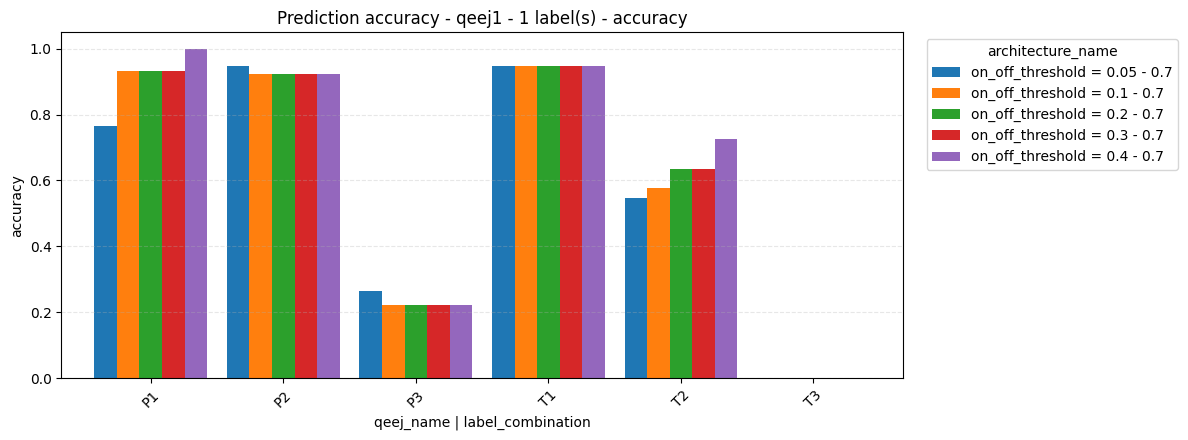

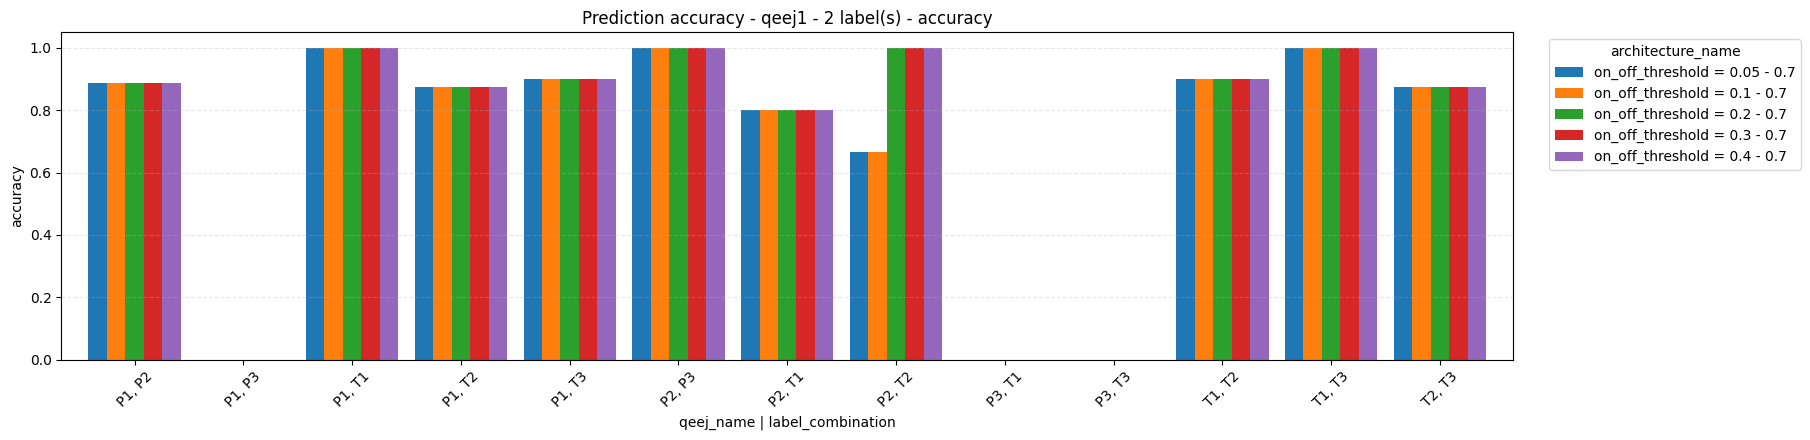

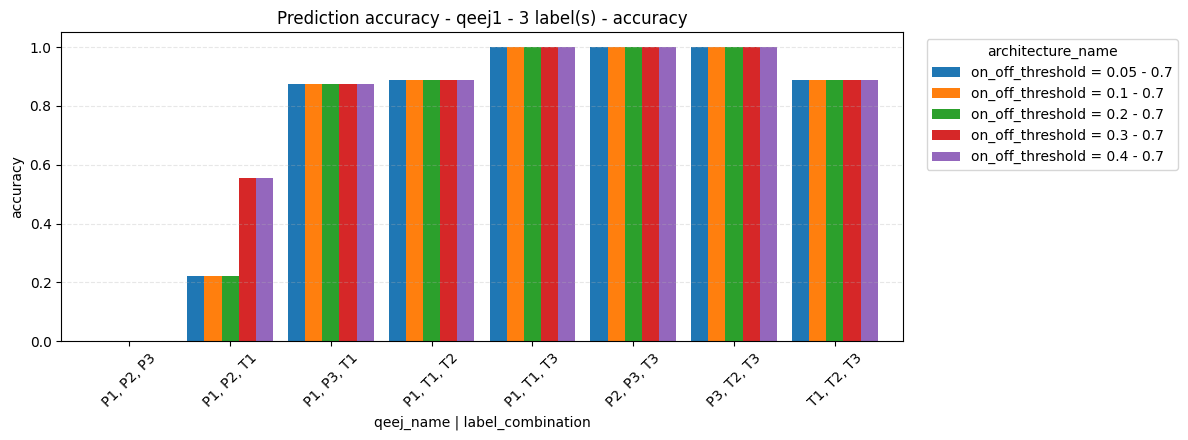

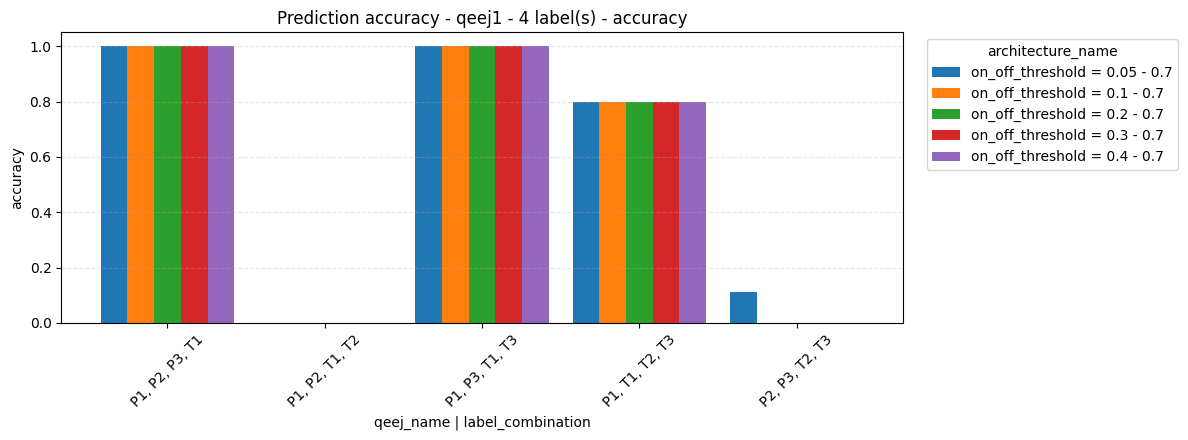

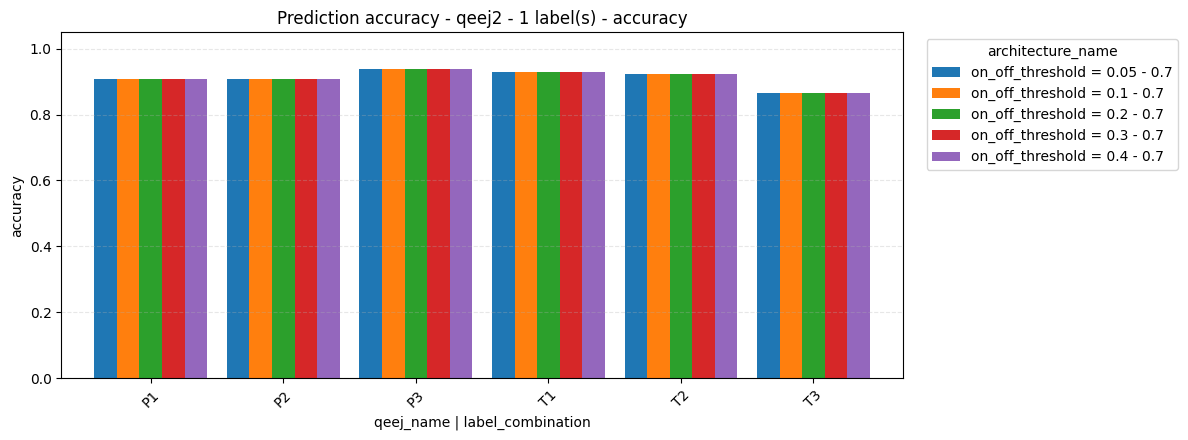

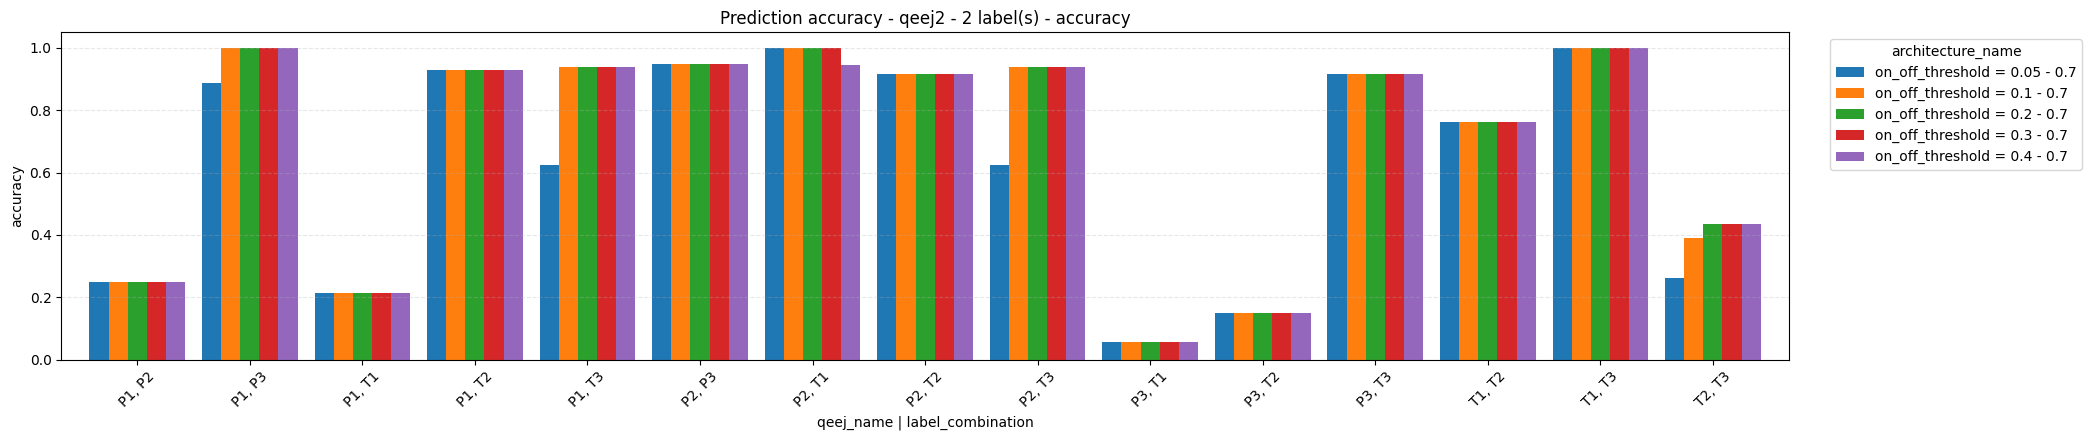

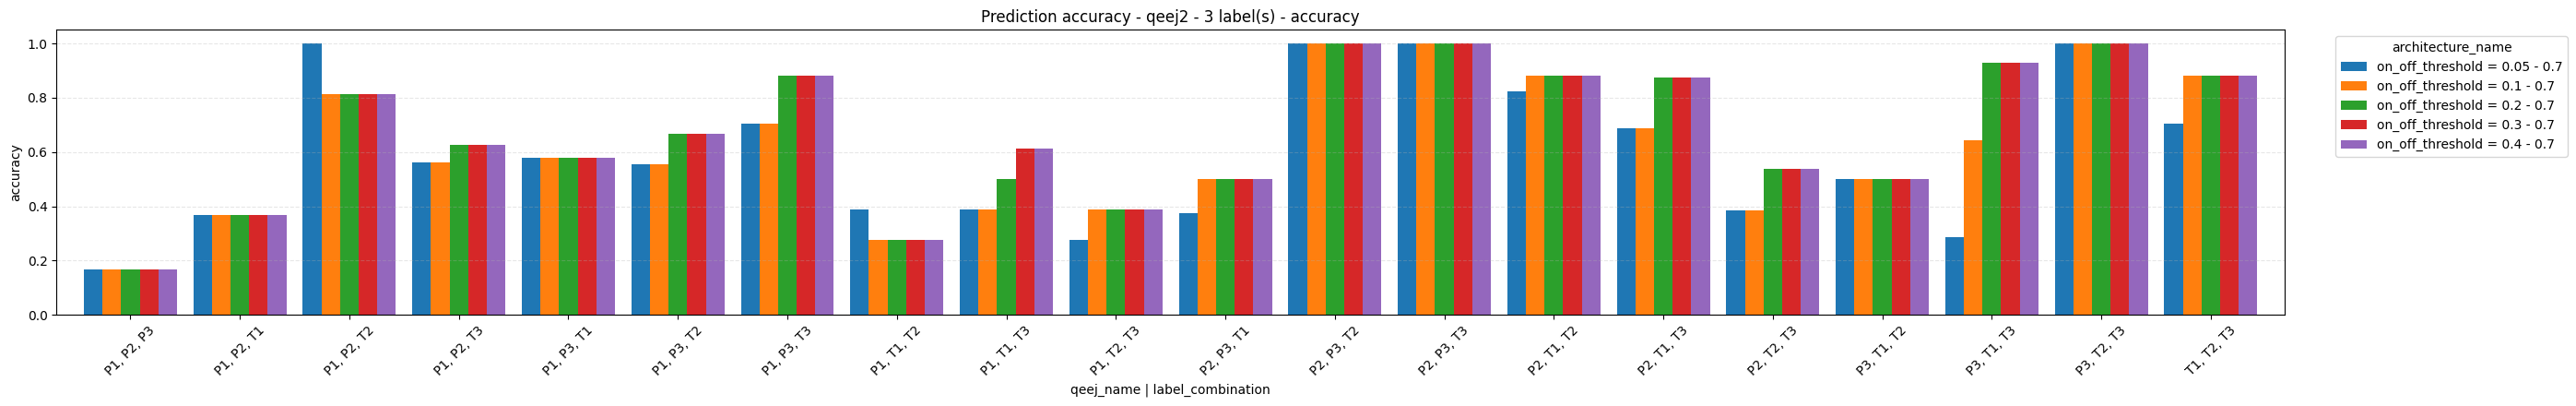

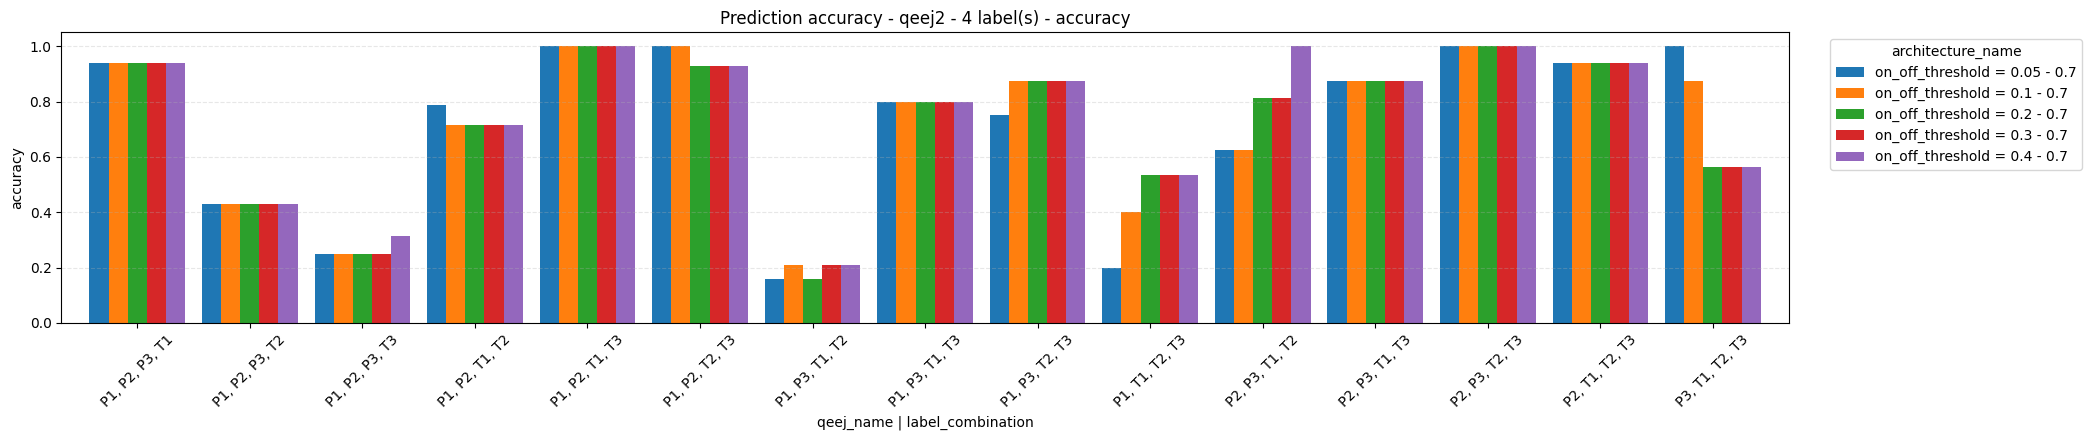

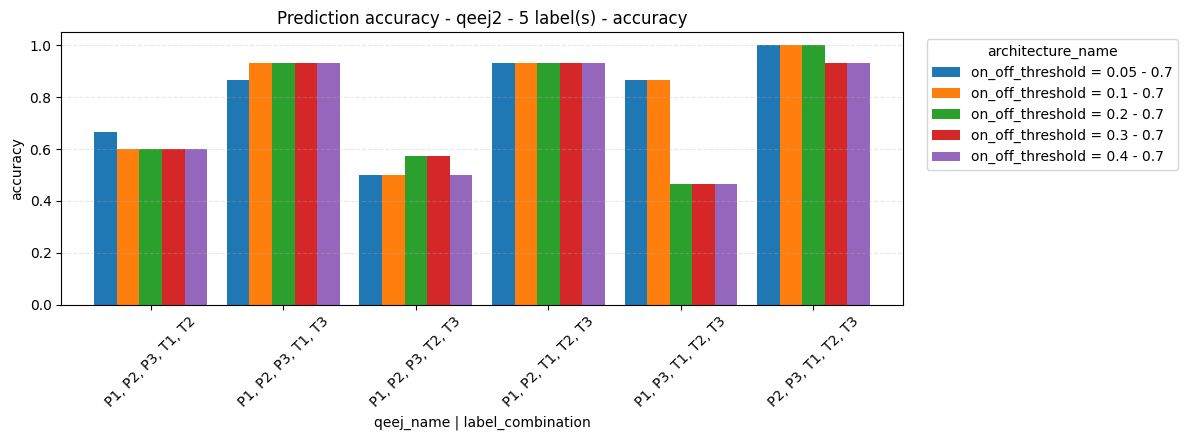

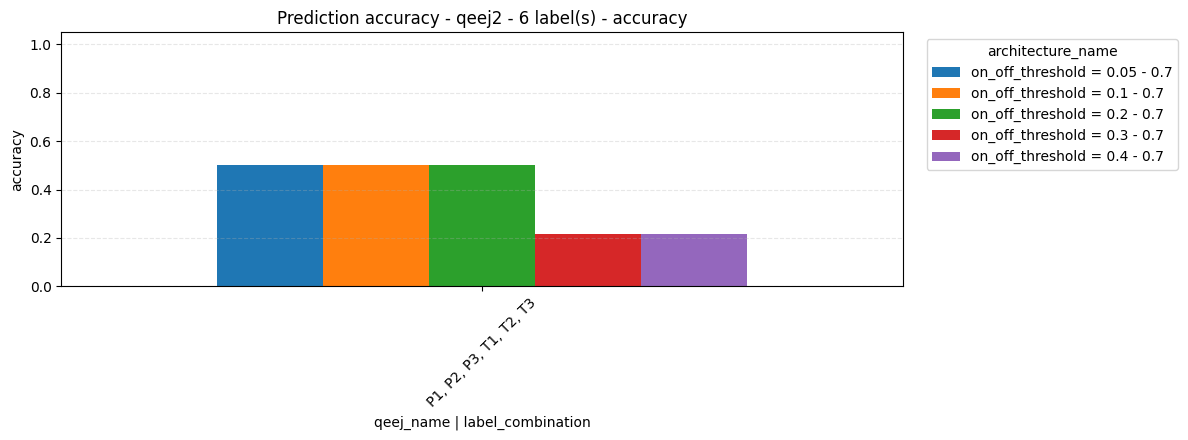

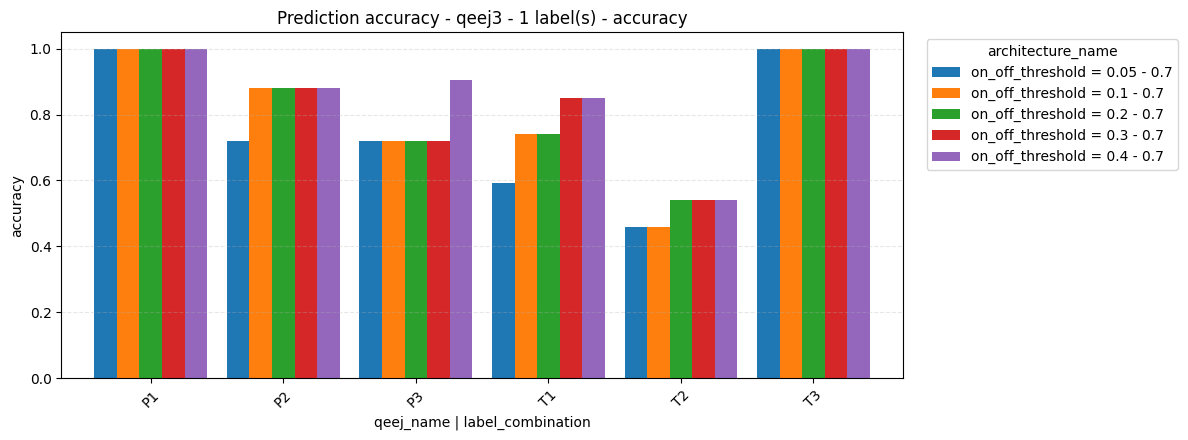

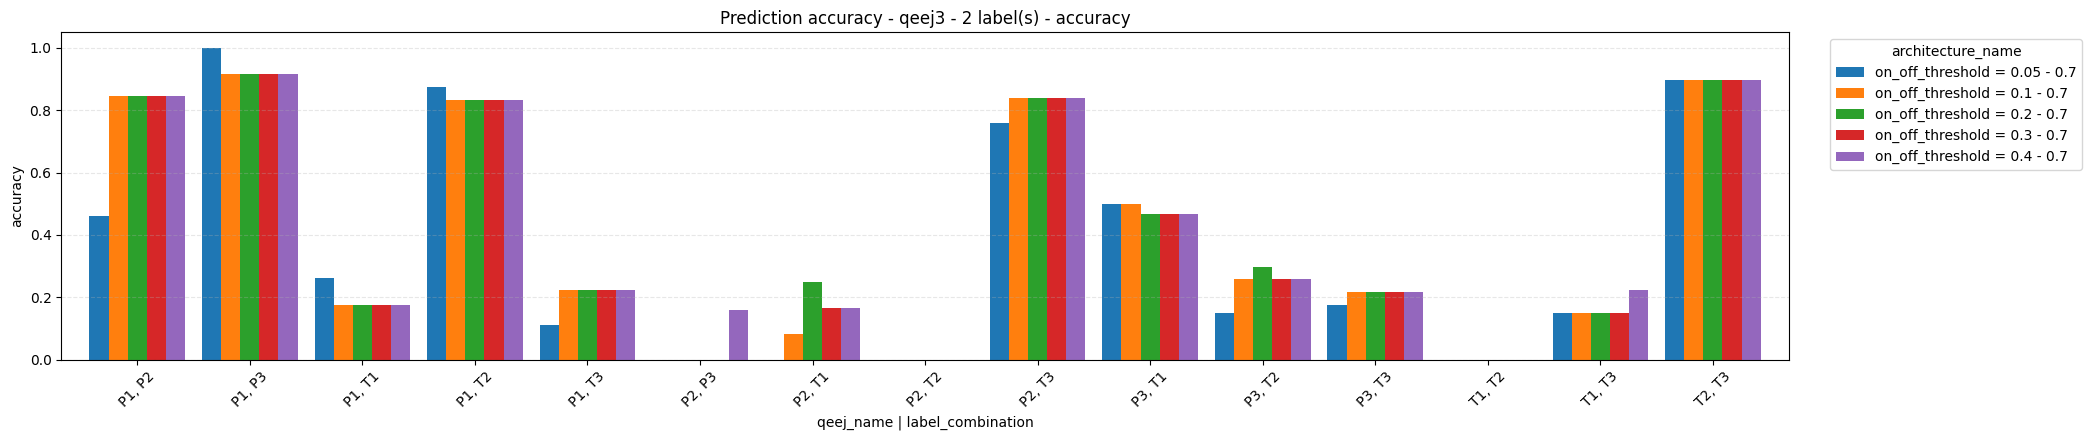

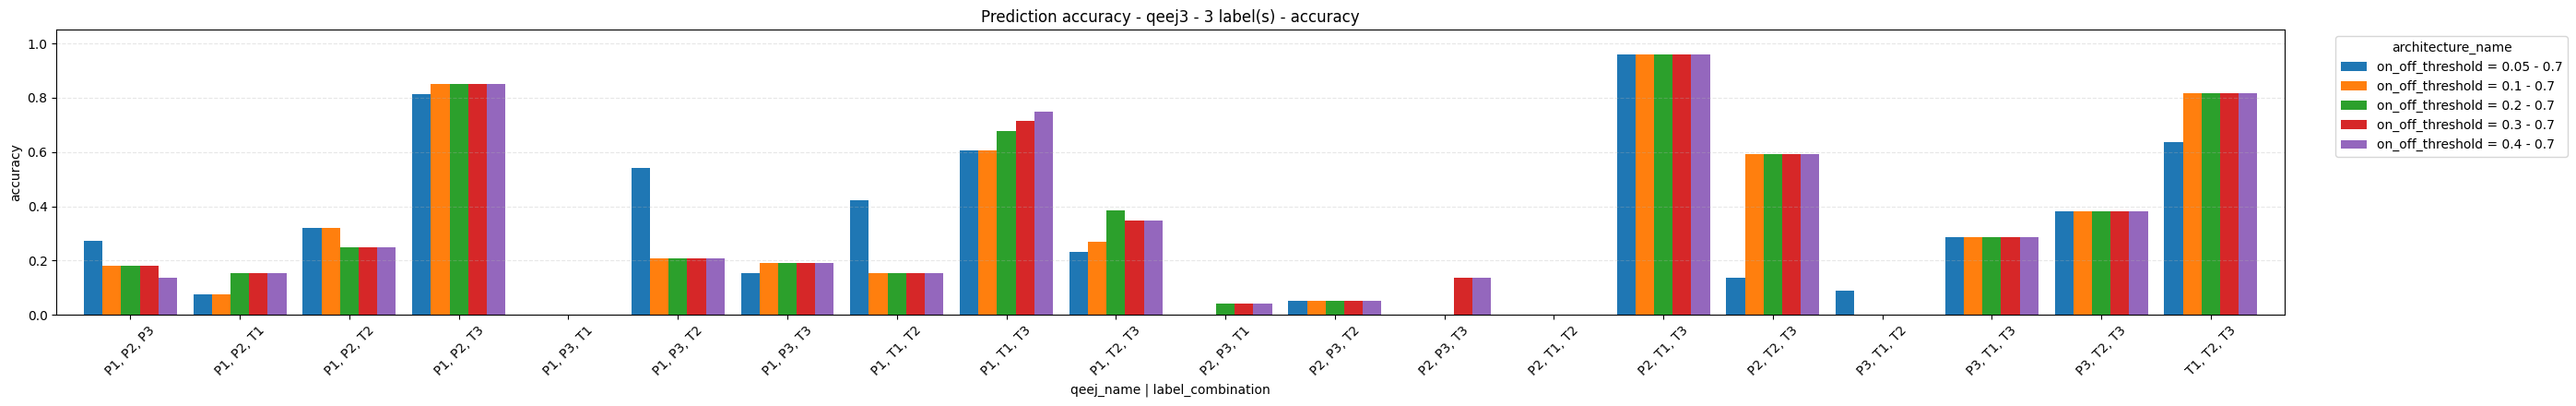

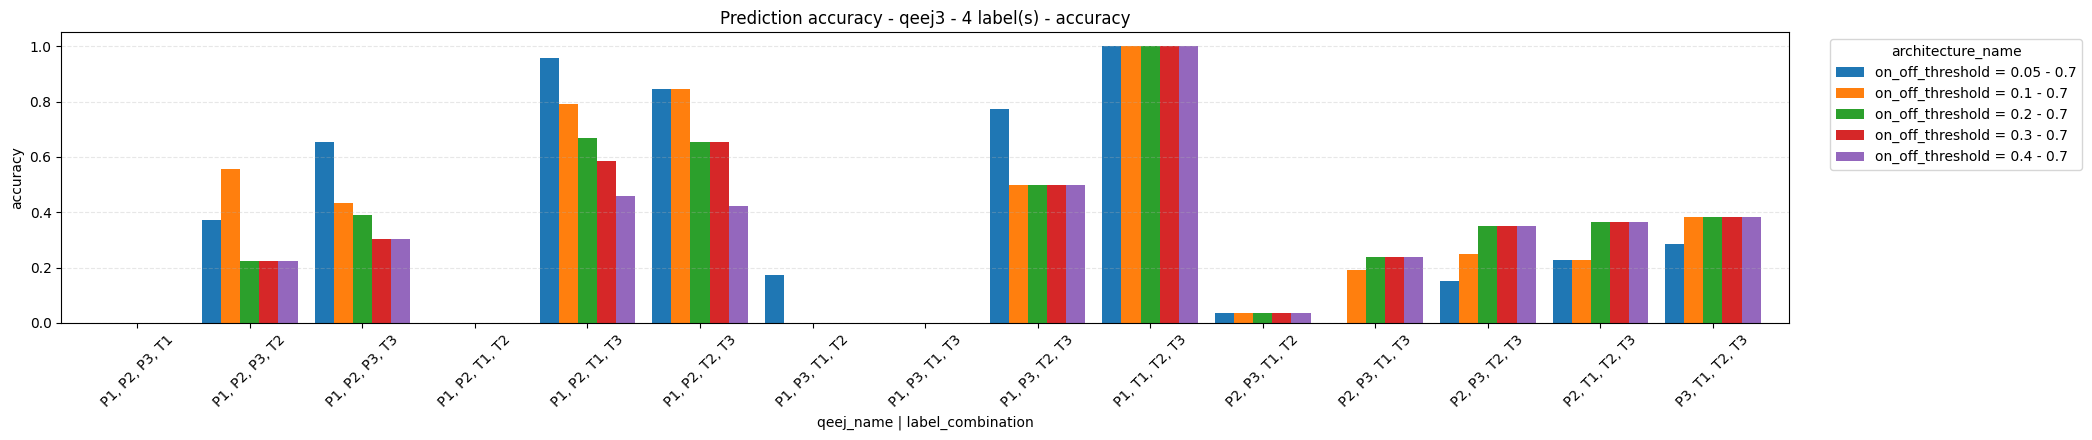

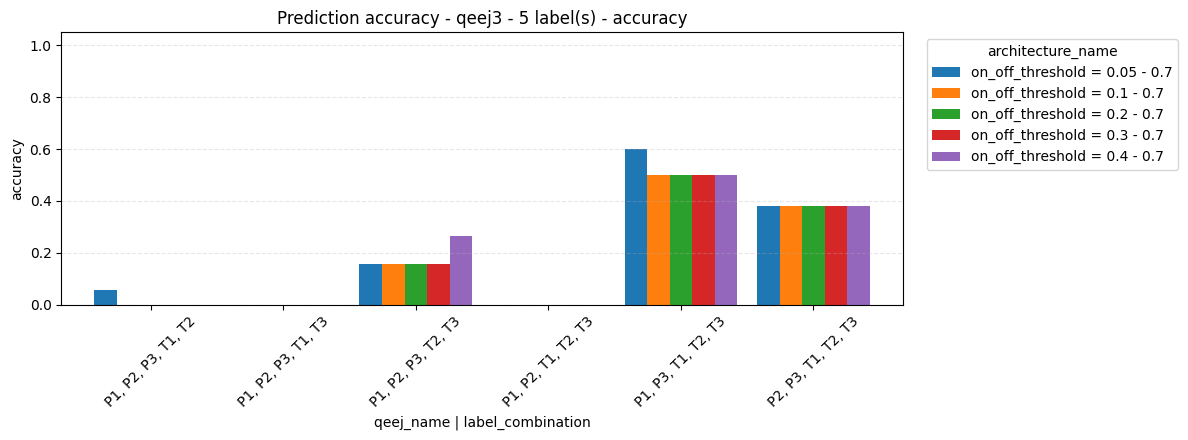

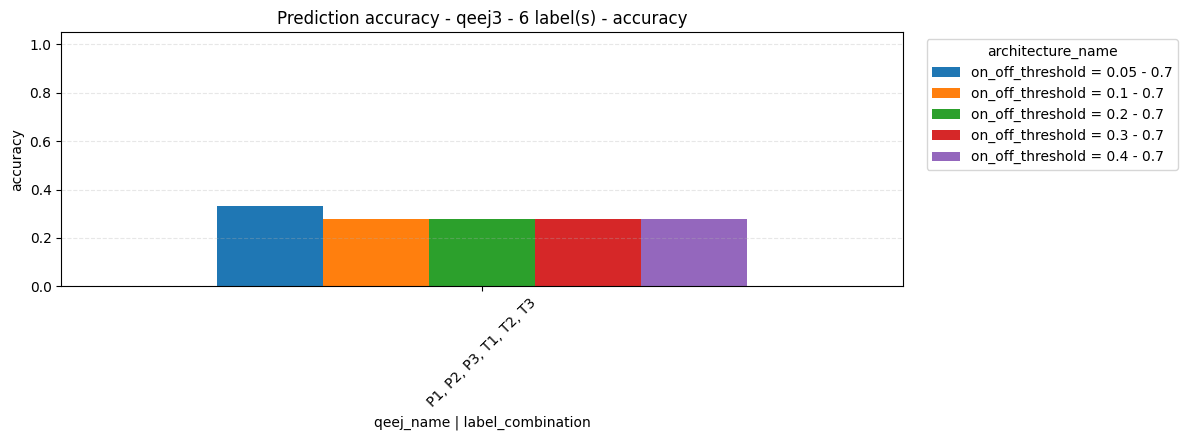

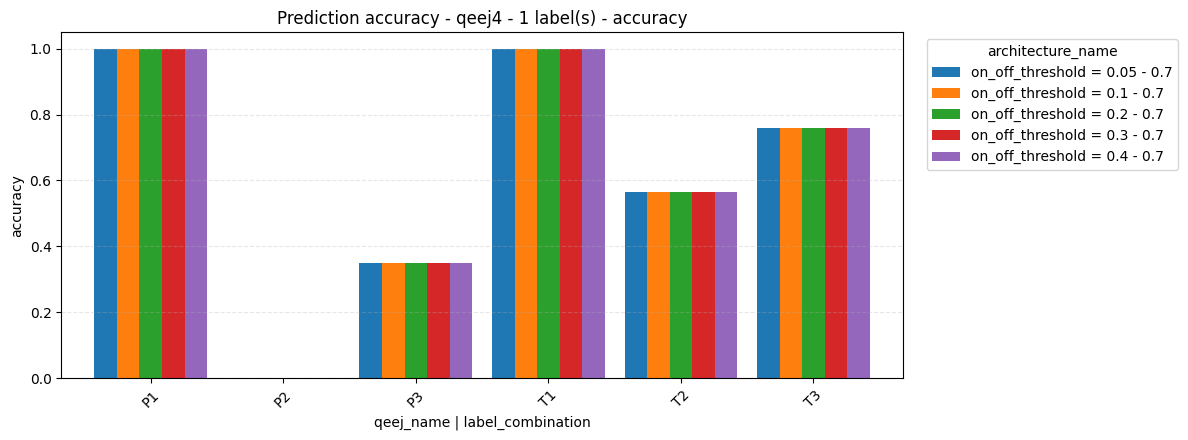

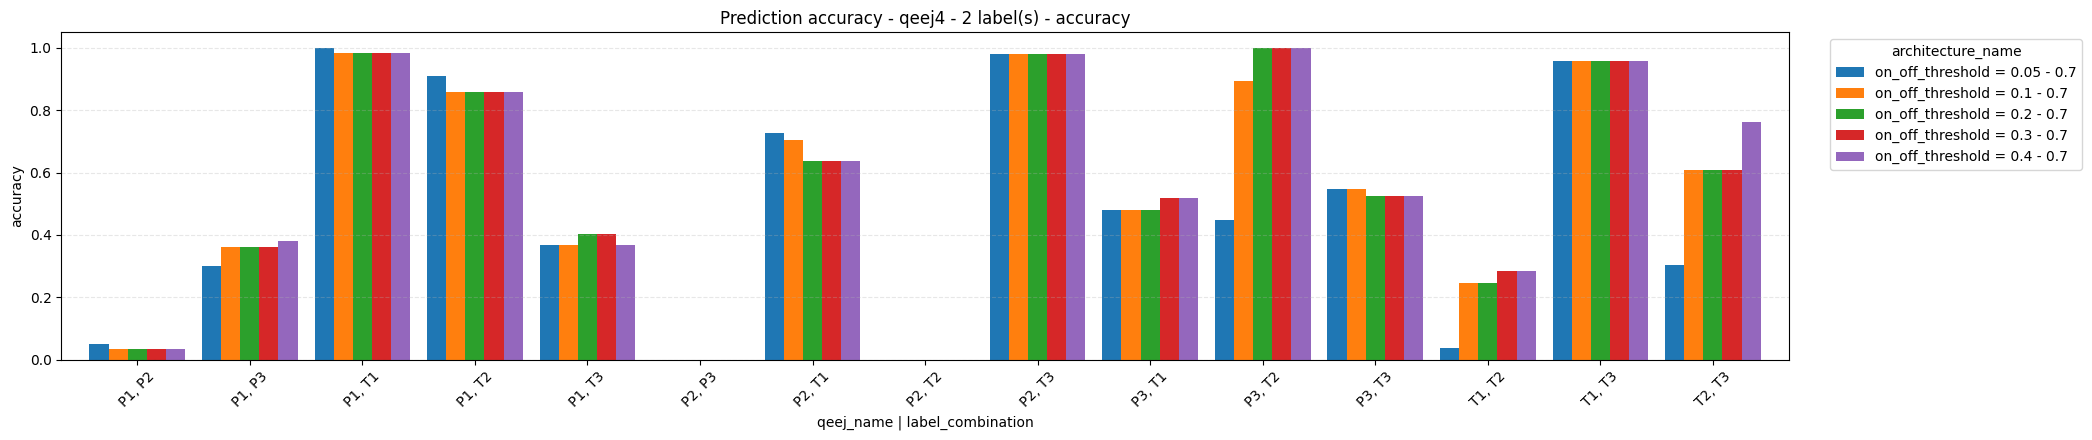

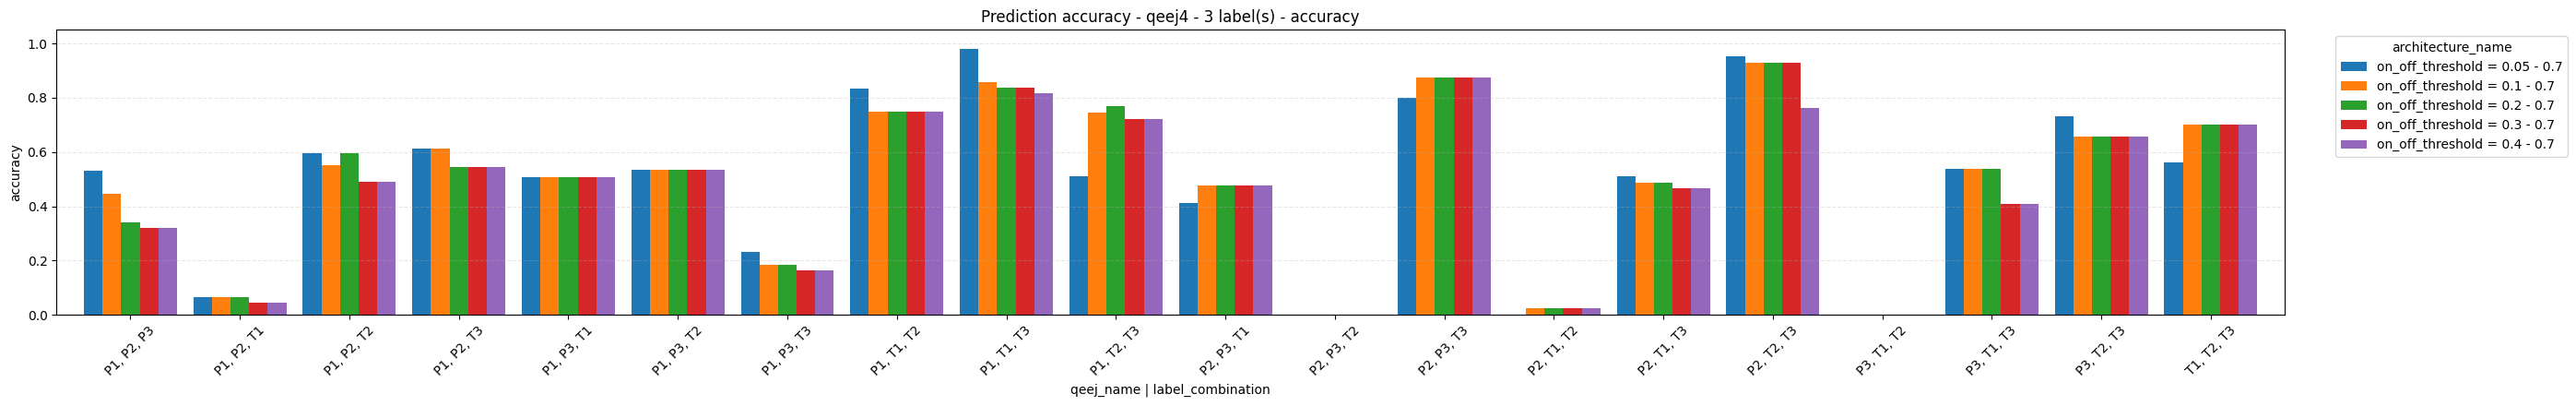

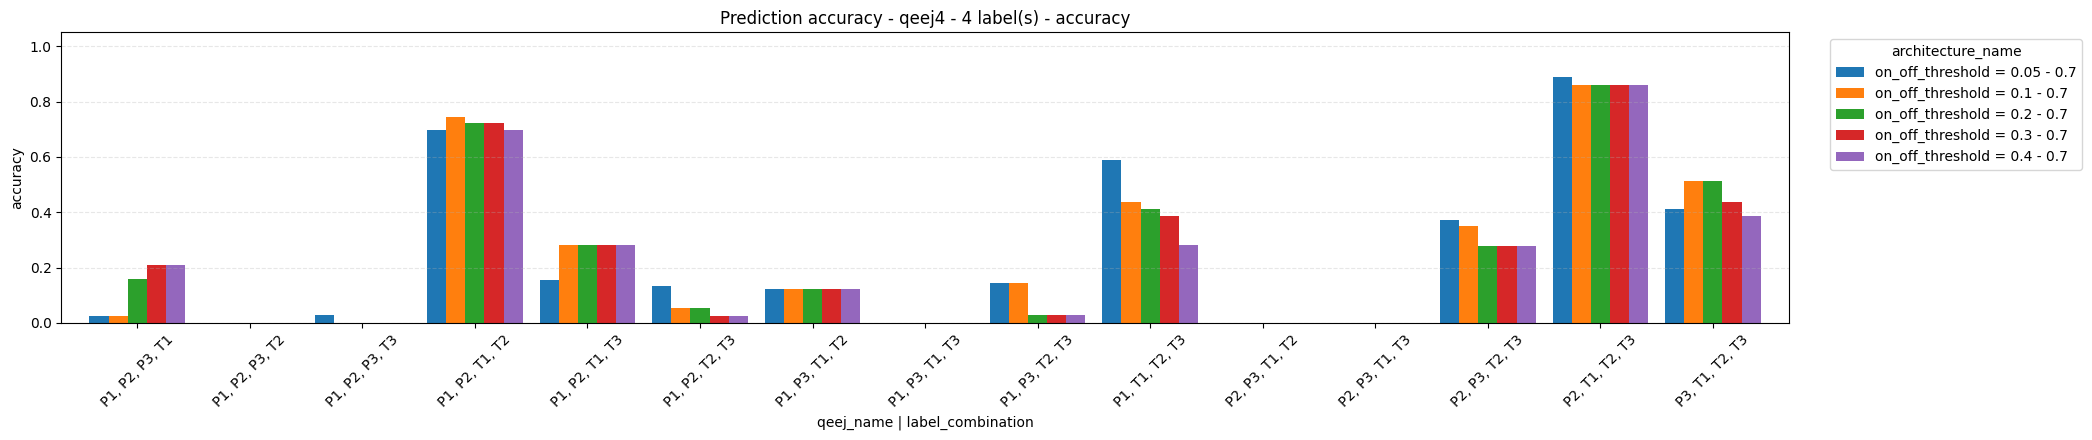

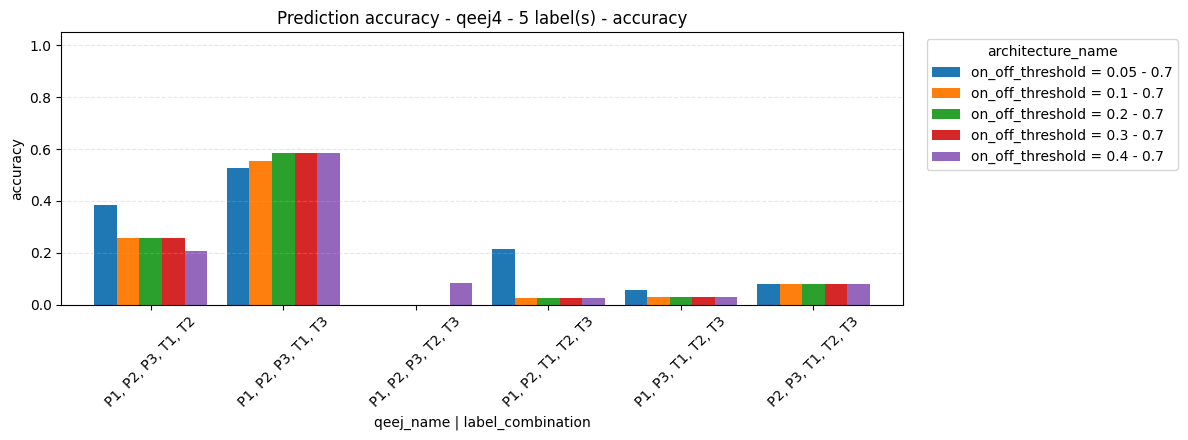

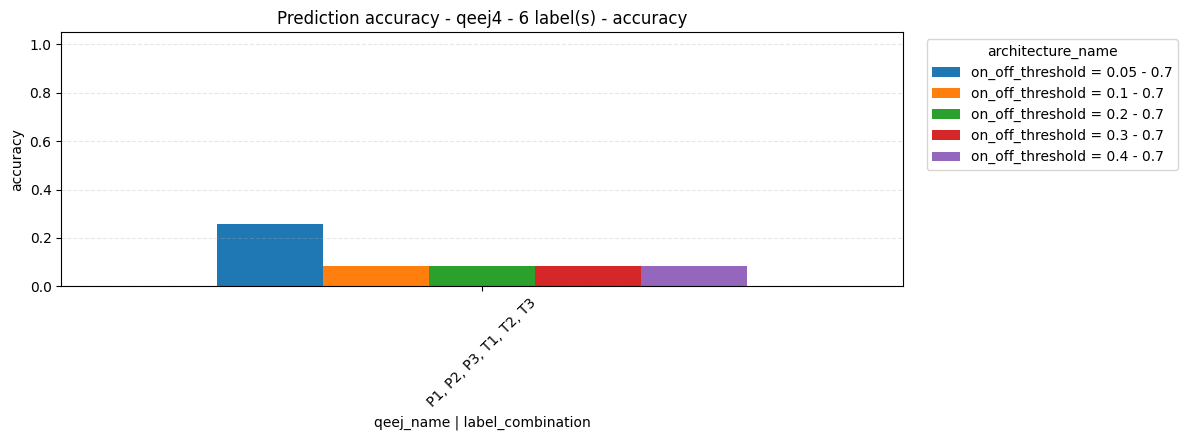

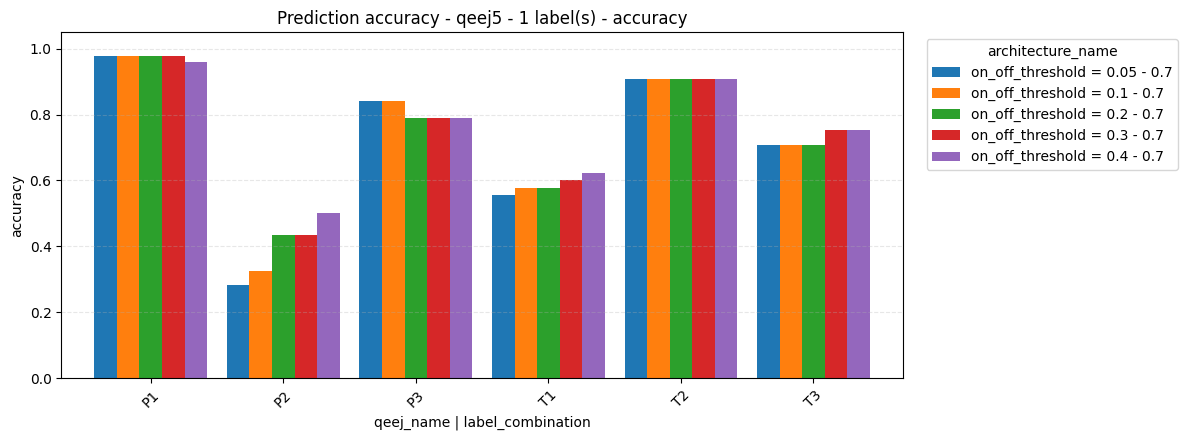

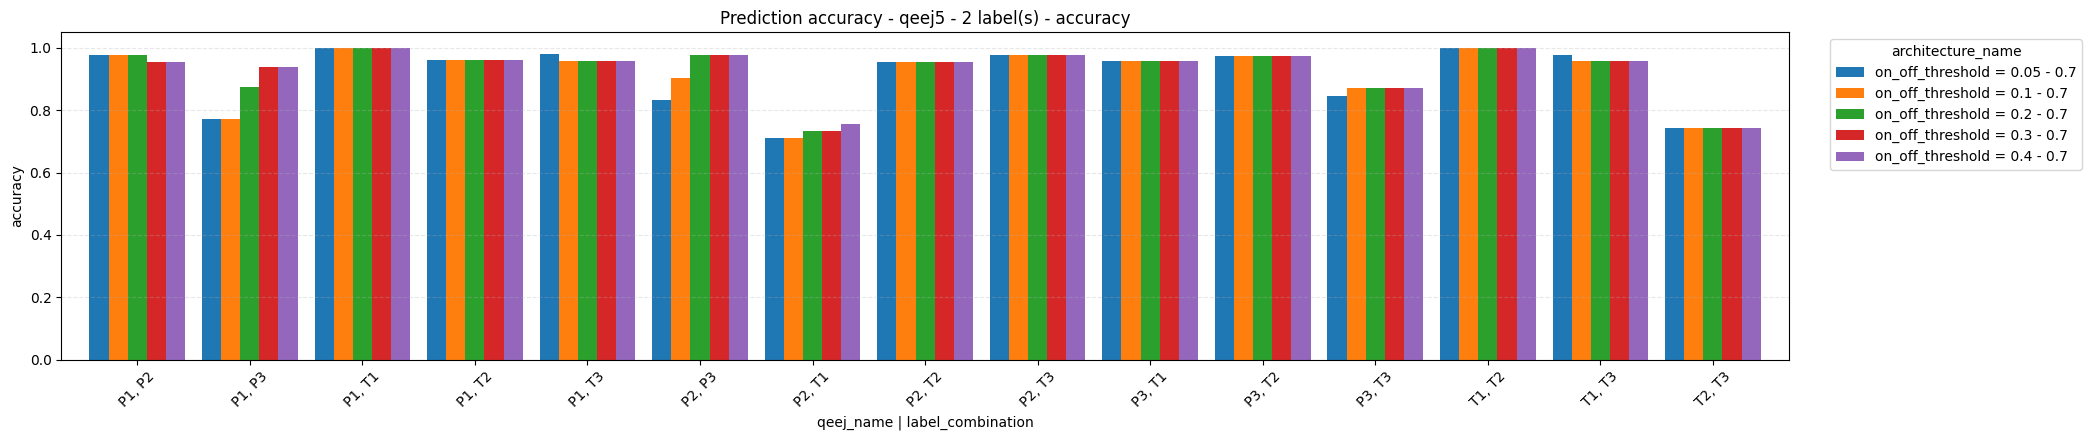

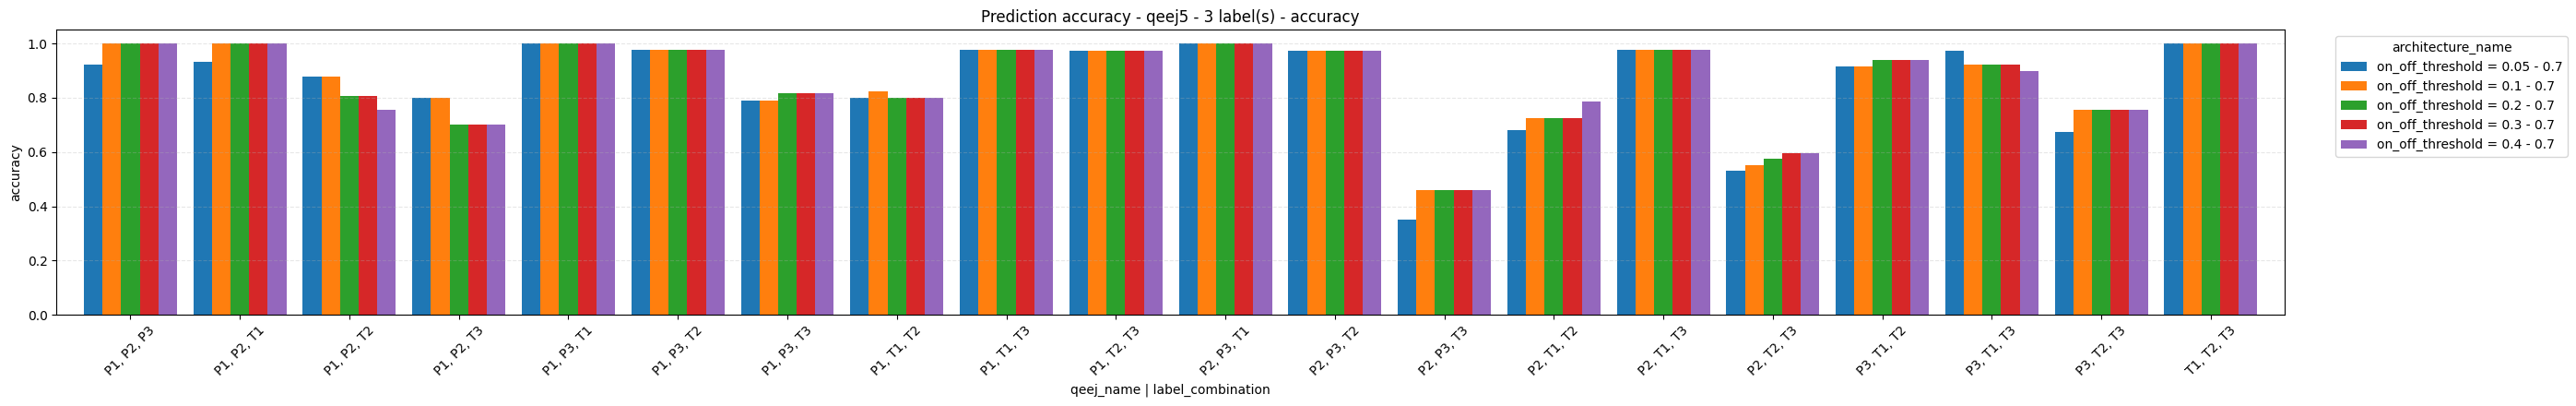

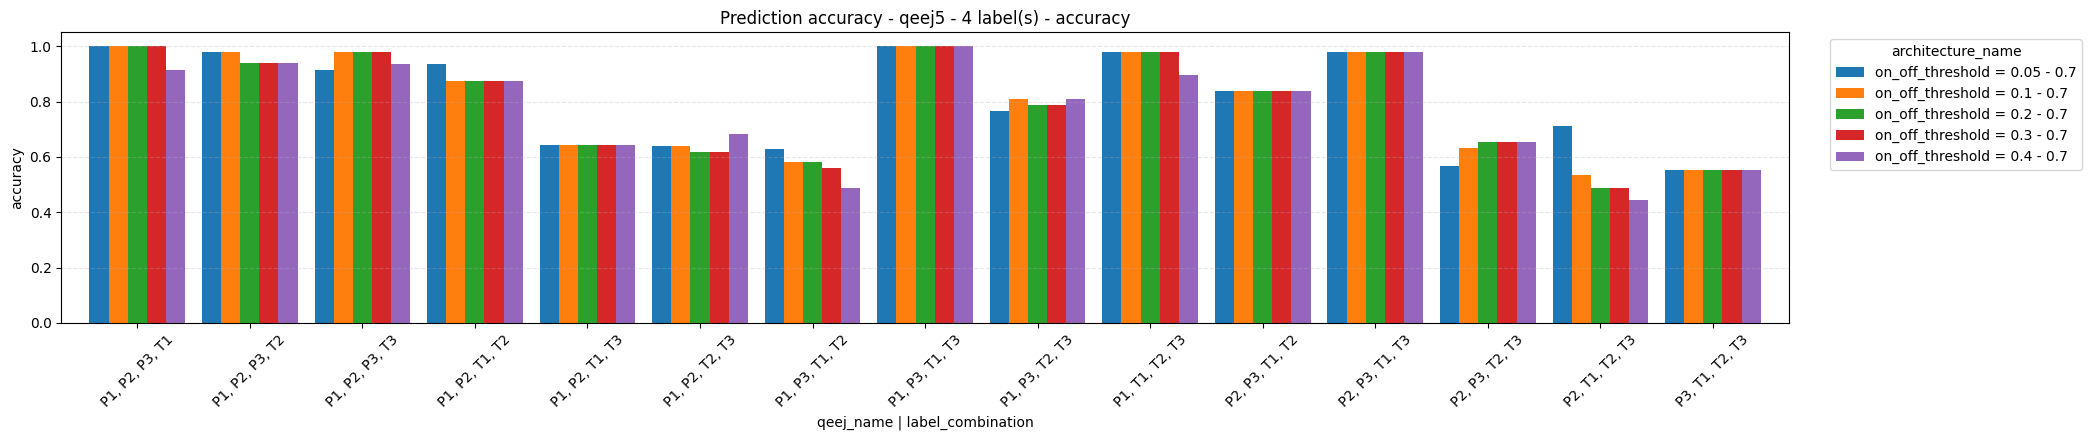

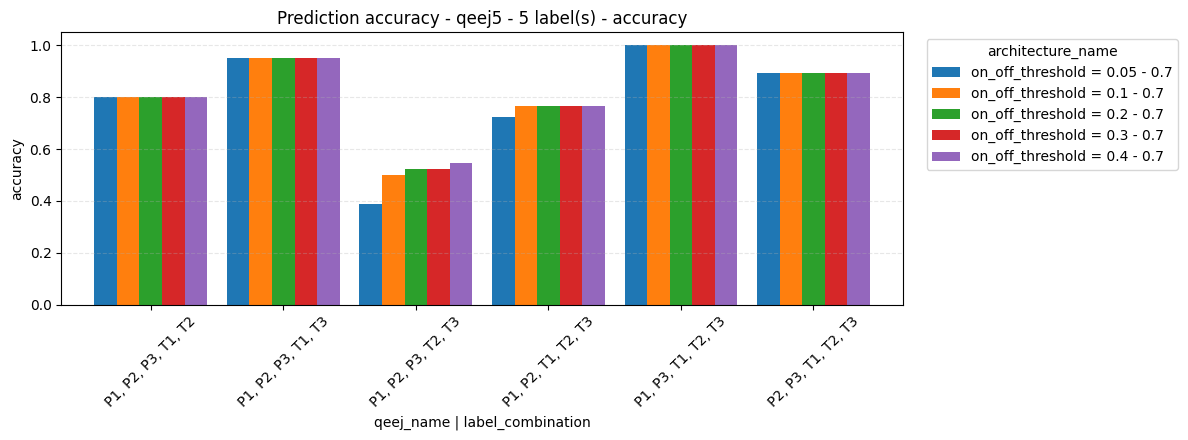

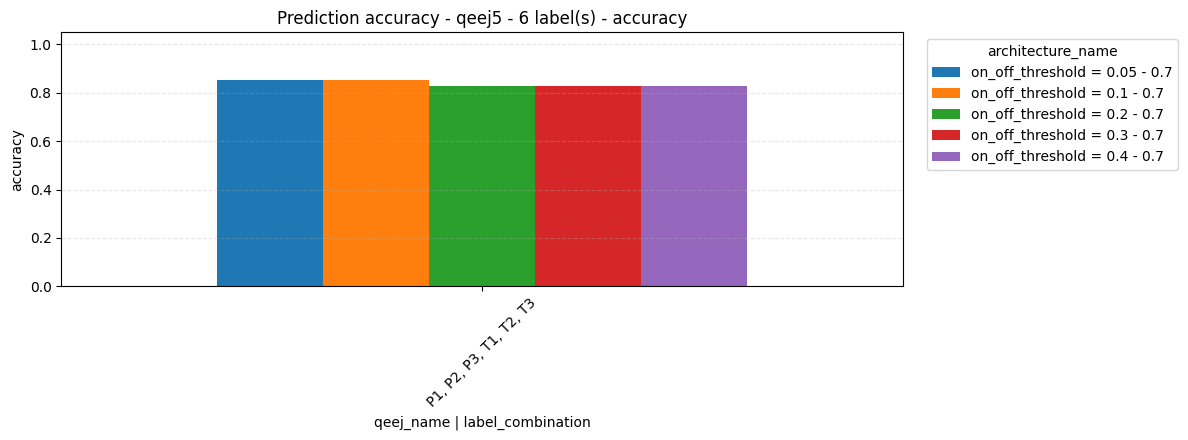

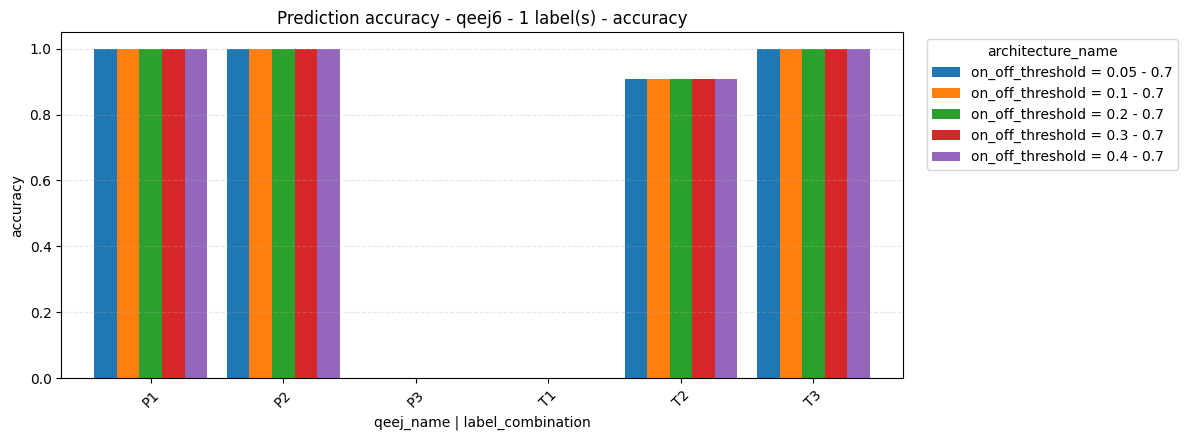

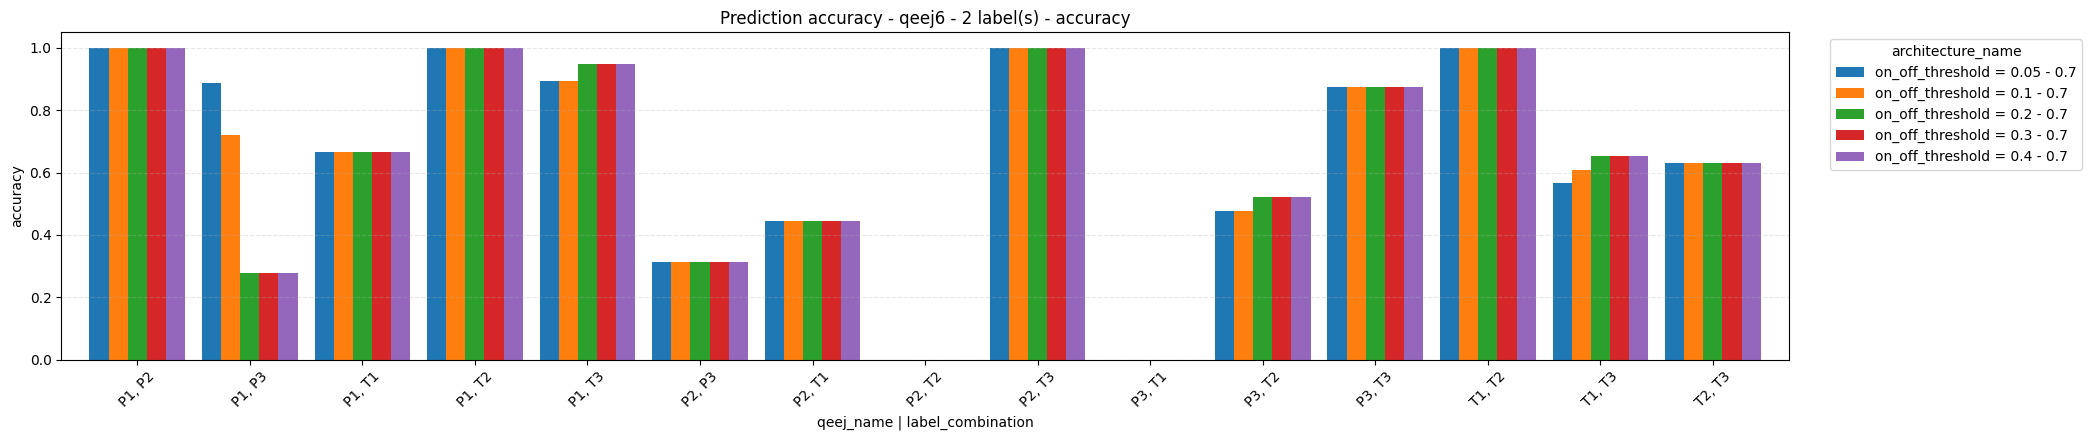

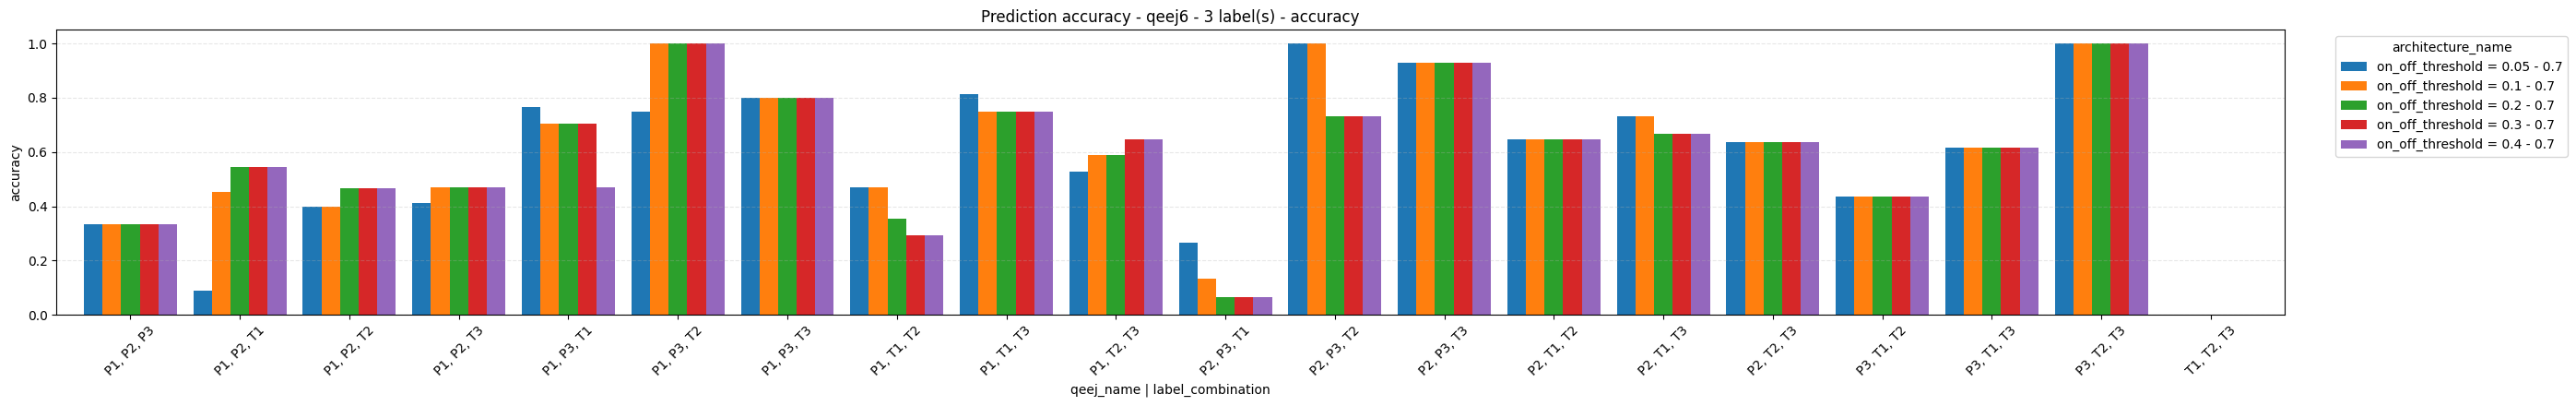

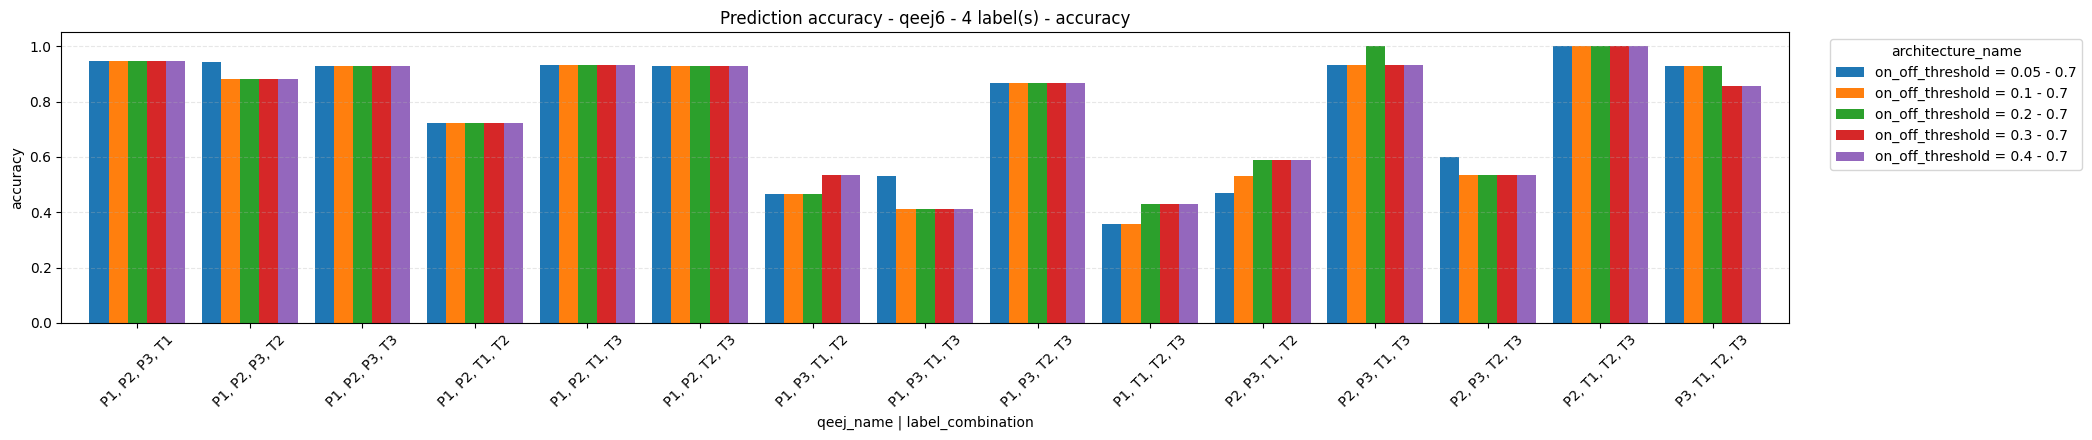

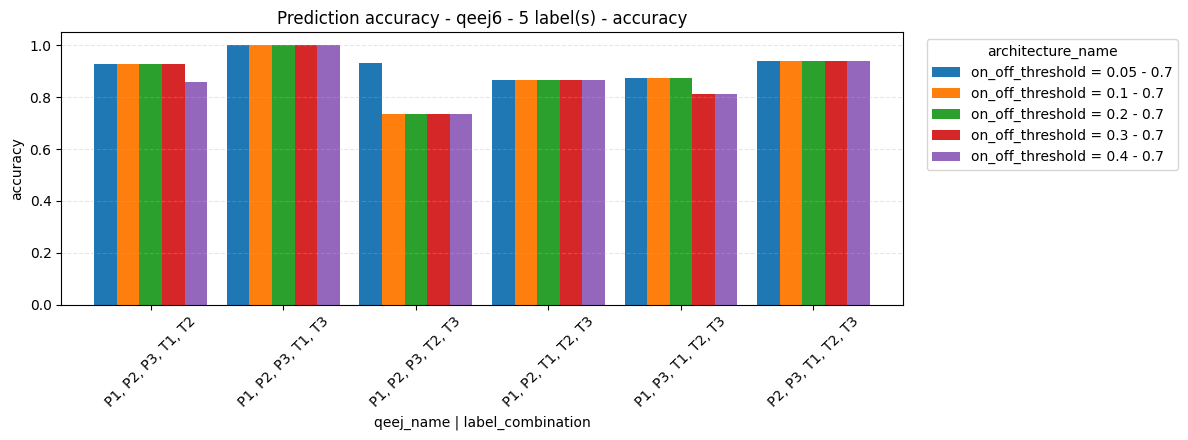

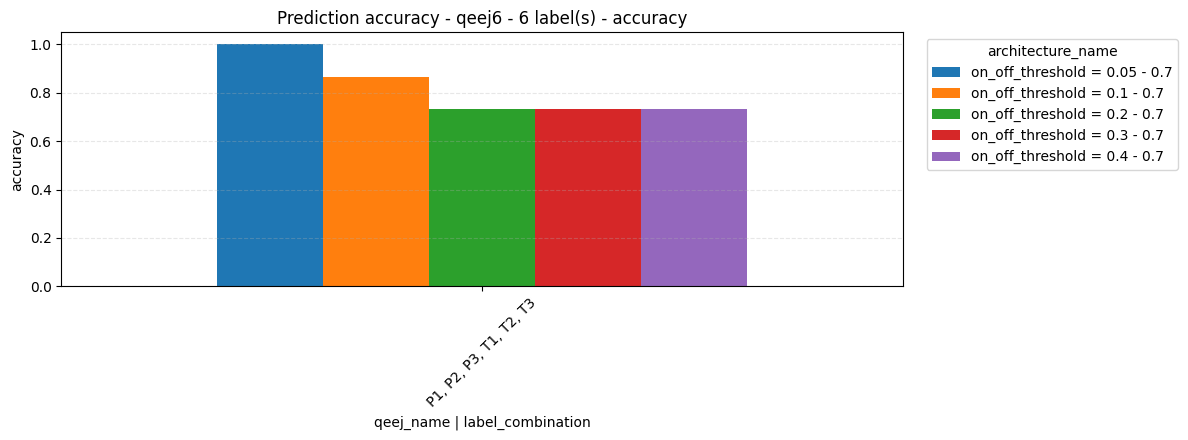

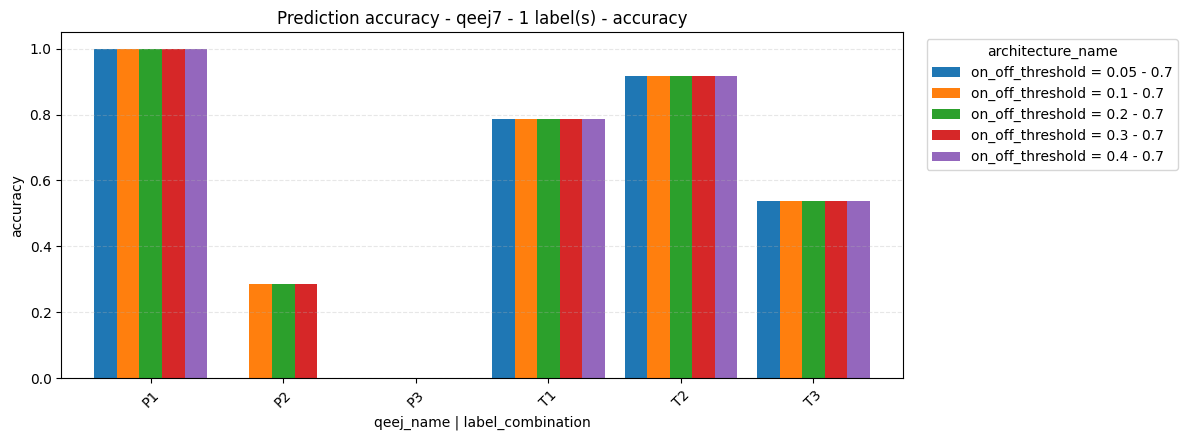

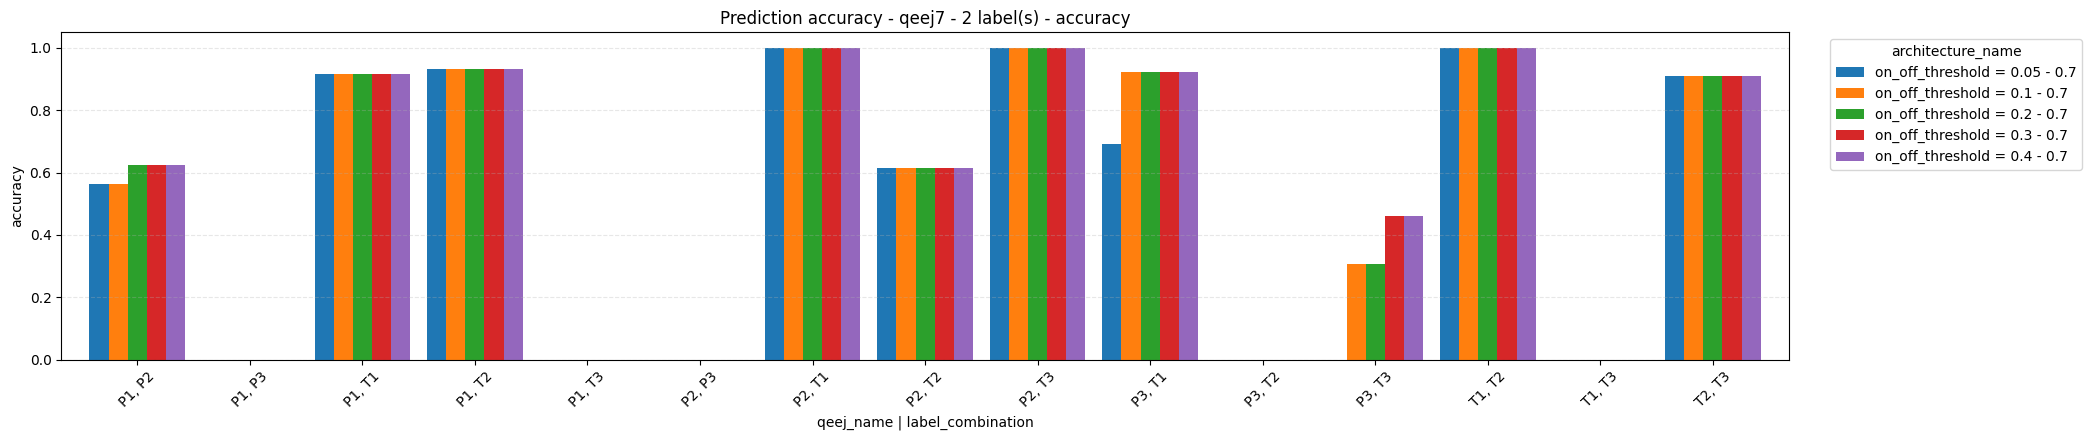

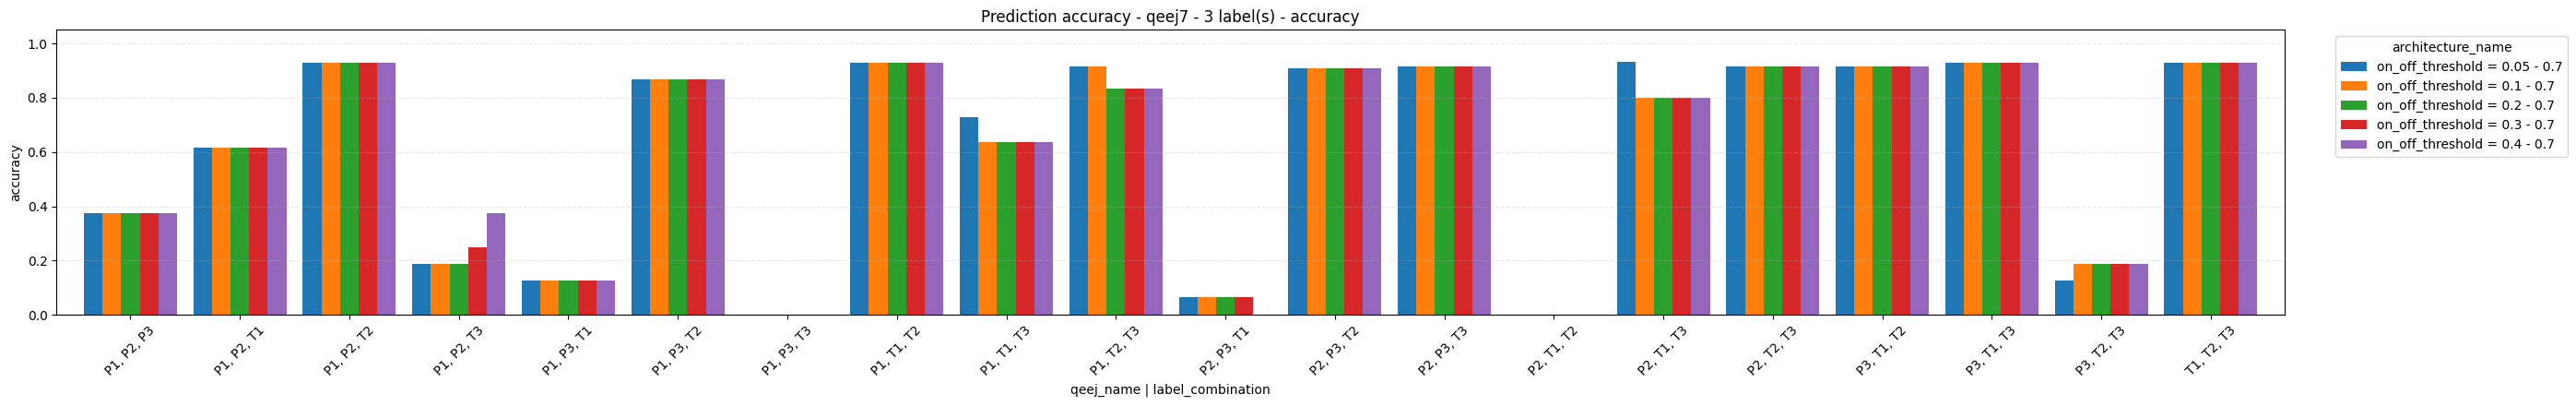

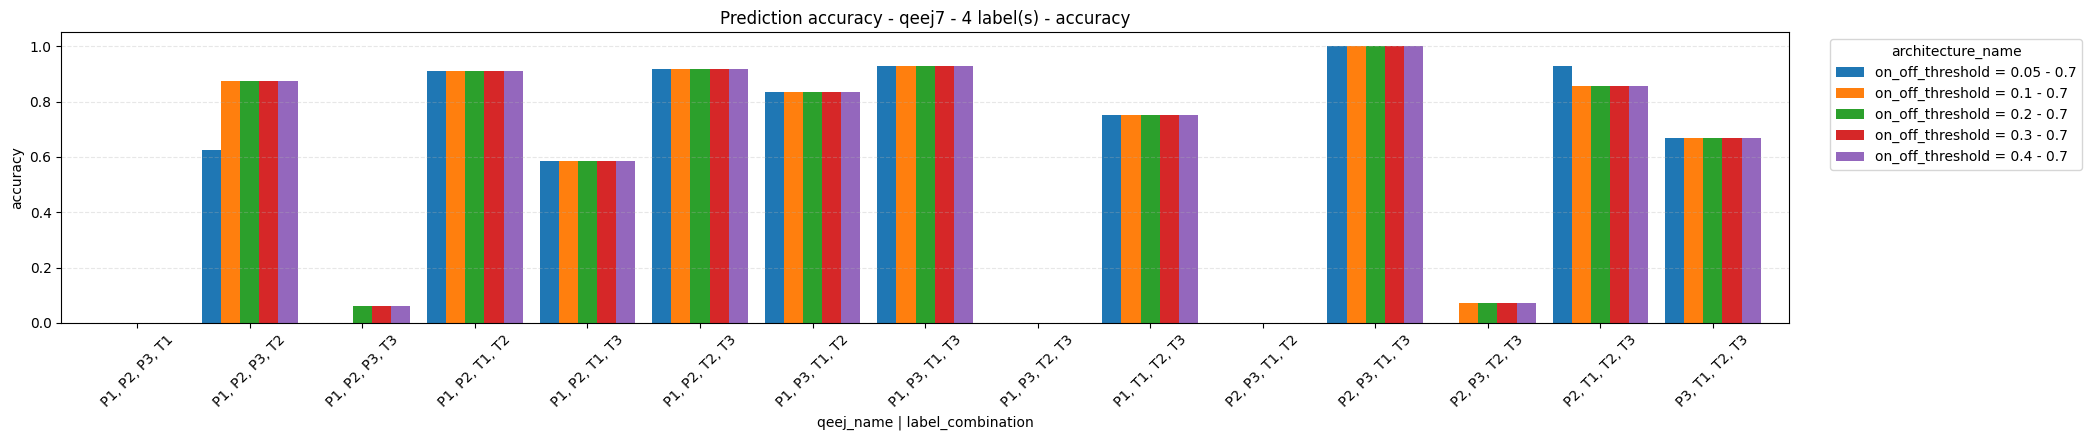

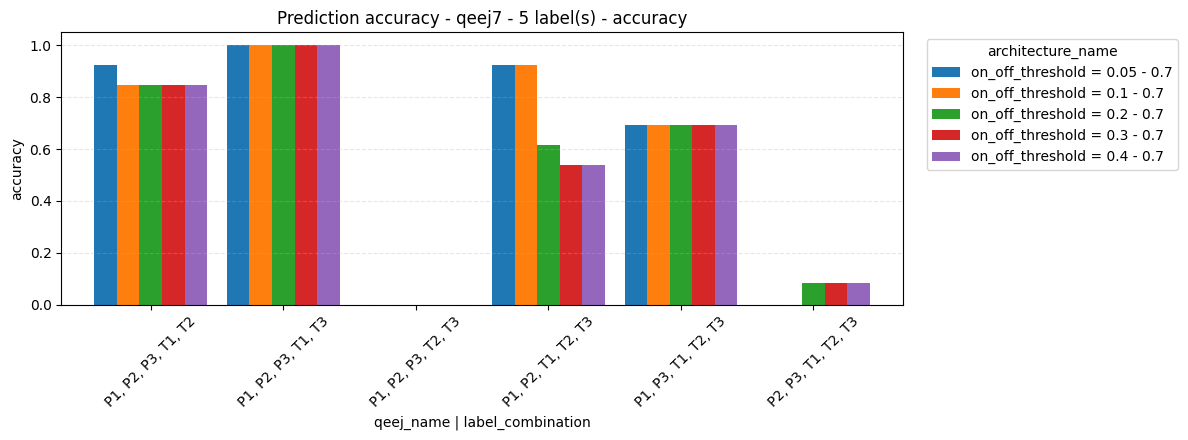

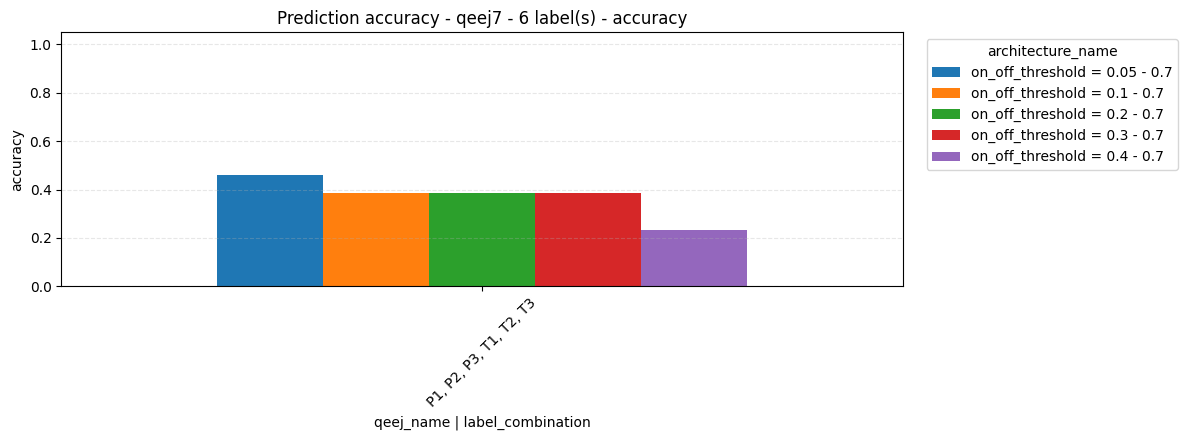

In [ ]:
qeej_names = sorted(aggregated_prediction_accuracy_df["qeej_name"].unique()) if not aggregated_prediction_accuracy_df.empty else []

for qeej_name in qeej_names:
    qeej_df = aggregated_prediction_accuracy_df[
        aggregated_prediction_accuracy_df["qeej_name"] == qeej_name
    ].copy()
    if qeej_df.empty:
        continue

    qeej_output_dir = os.path.join(QEEJ_EVAL_OUTPUT_DIR, qeej_name)
    os.makedirs(qeej_output_dir, exist_ok=True)
    qeej_summary_path = os.path.join(qeej_output_dir, "accuracy_summary.csv")
    qeej_df.to_csv(qeej_summary_path, index=False, encoding="utf-8-sig")

    qeej_df["test_case"] = qeej_df["label_combination"]
    title = f"Prediction accuracy - {qeej_name}"
    plots_dir = os.path.join(qeej_output_dir, QEEJ_PLOTS_DIRNAME)
    save_plot_prediction_accuracy_by_label_count(
        aggregated_df=qeej_df,
        title_prefix=title,
        display_columns=["qeej_name", "label_combination"] + PREDICTION_DISPLAY_COLUMNS,
        save_dir=plots_dir,
    )

### Save plots summarizing accuracy of each qeej between each model's architecture

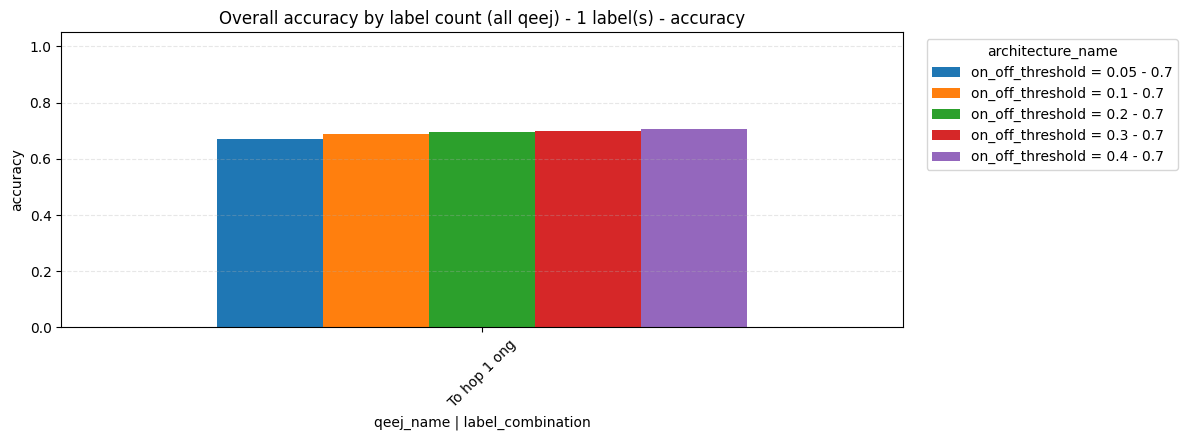

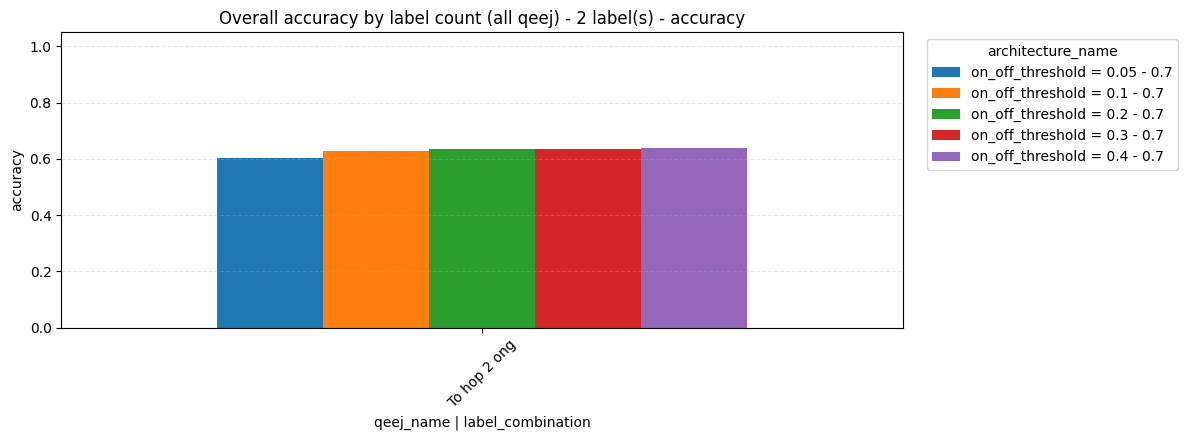

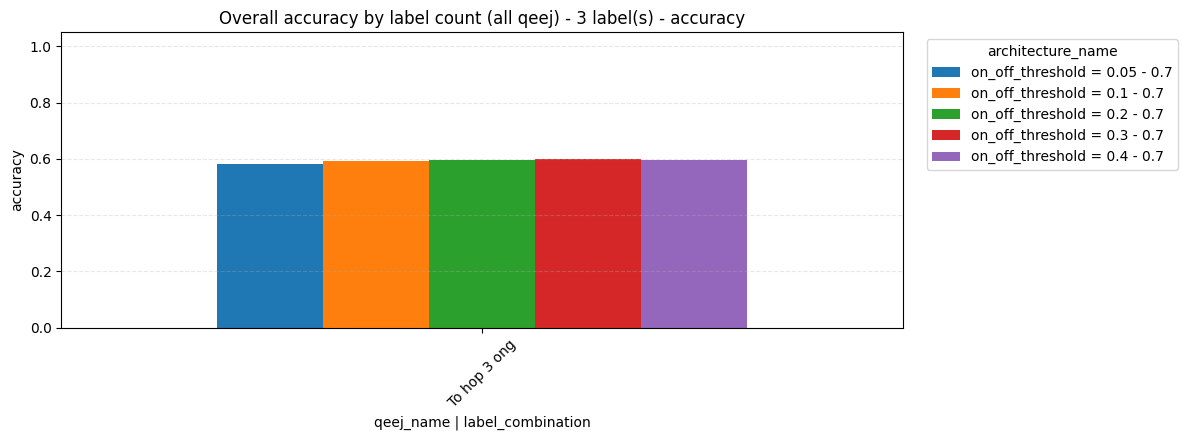

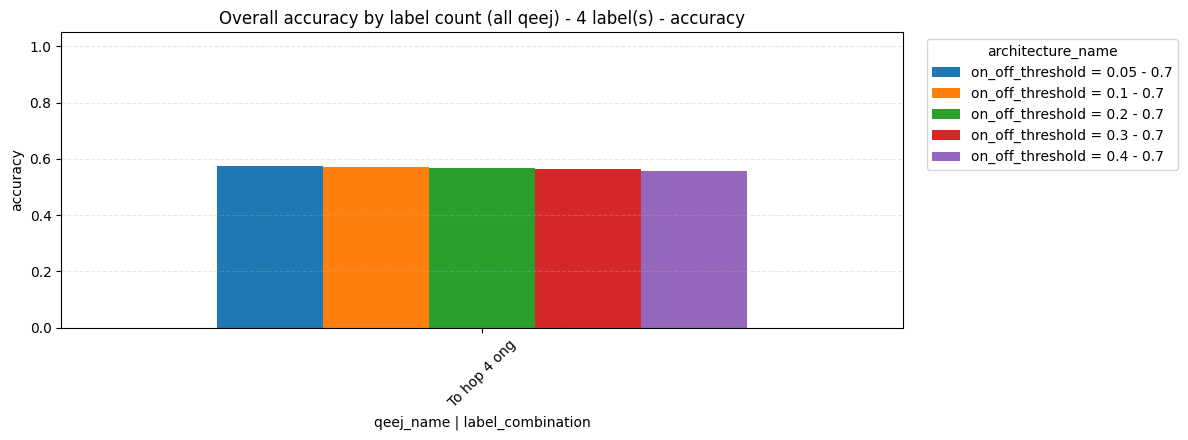

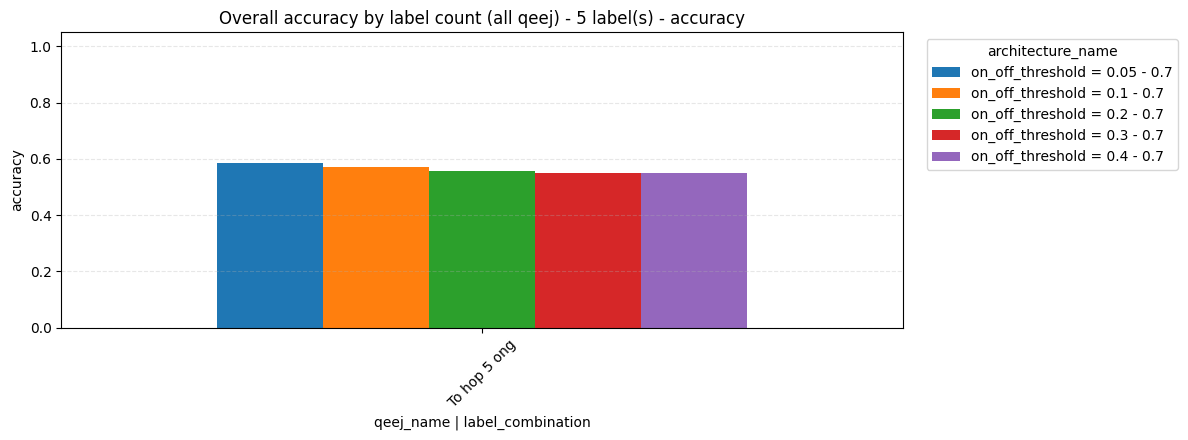

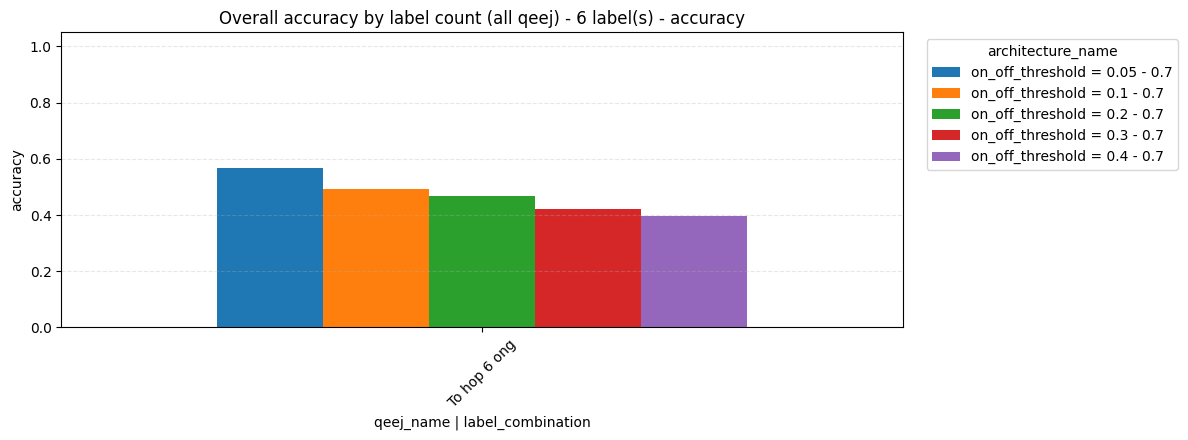

In [ ]:

overall_combo_df = pd.DataFrame()
if not prediction_accuracy_df.empty:
    overall_combo_plot_df = (
        prediction_accuracy_df
        .groupby(["architecture_name", "label_count"], as_index=False)
        .agg({
            "correct_sample": "sum",
            "total_sample": "sum",
            "test_file_name": "count",
            "accuracy": "mean",
        })
        .rename(columns={"test_file_name": "num_test_files"})
        .sort_values(["label_count", "architecture_name"])
    )
    overall_combo_plot_df["label_combination"] = overall_combo_plot_df["label_count"].apply(
        lambda x: f"To hop {int(x)} ong"
    )
    overall_combo_plot_df["test_case"] = overall_combo_plot_df["label_combination"]

    overall_combo_df = (
        overall_combo_plot_df
        .pivot(index="label_combination", columns="architecture_name", values="accuracy")
        .reindex(overall_combo_plot_df["label_combination"].drop_duplicates())
    )

    architecture_columns = [
        architecture_name
        for architecture_name in EVALUATED_ARCHITECTURE_MODEL
        if architecture_name in overall_combo_df.columns
    ]
    remaining_columns = [
        column_name
        for column_name in overall_combo_df.columns
        if column_name not in architecture_columns
    ]
    overall_combo_df = overall_combo_df[architecture_columns + remaining_columns]
    overall_combo_df.index.name = "label_count_group"

    overall_summary_path = os.path.join(QEEJ_EVAL_OUTPUT_DIR, "overall_accuracy_by_label_count.csv")
    overall_combo_df.to_csv(overall_summary_path, encoding="utf-8-sig")

    save_plot_prediction_accuracy_by_label_count(
        aggregated_df=overall_combo_plot_df,
        title_prefix="Overall accuracy by label count (all qeej)",
        display_columns=["label_combination", "architecture_name", "accuracy"],
        save_dir=OVERALL_PLOTS_DIR,
    )



## Evaluate model performance by note-level

In [ ]:

frame_to_second = hop_length/48000
NOTE_MIDI_MAP = {
    "P1": librosa.note_to_hz('D5'),
    "P2": librosa.note_to_hz('A4'),
    "P3": librosa.note_to_hz('G4'),
    "T1": librosa.note_to_hz('C5'),
    "T2": librosa.note_to_hz('D4'),
    "T3": librosa.note_to_hz('F4'),
}

In [ ]:
def get_note_and_time_active_of_true_label(true_path, prediction_df):
    labels, frame_intervals = load_true_labels_for_prediction(true_path, prediction_df)

    # print("check labels: ", labels)
    # print("frame_intervals: ", frame_intervals)

    onset_offset_dict = {}
    for idx, label in enumerate(labels):
        if label == "silence":
            continue
        individual_labels = label.split(",")
        start_frame, end_frame = frame_intervals[idx]
        for l in individual_labels:
            l = l.strip()
            if l not in onset_offset_dict:
               onset_offset_dict[l] = [{
                   "onset": start_frame * frame_to_second,
                   "offset": end_frame * frame_to_second
               }]
            else:
              last_time_exist = float(onset_offset_dict[l][-1]["offset"])
              start_time = float(start_frame * frame_to_second)
              if last_time_exist == start_time:
                onset_offset_dict[l][-1]["offset"] = end_frame * frame_to_second
              else:
                onset_offset_dict[l].append({
                   "onset": start_frame * frame_to_second,
                   "offset": end_frame * frame_to_second
               })
    return dict(sorted(onset_offset_dict.items()))

def get_note_and_time_active_of_predict_label(prediction_path):
    prediction_df = pd.read_csv(prediction_path)
    onset_offset_dict = {}
    labels = prediction_df["label"]
    times = prediction_df["Times"]
    for idx, label in enumerate(labels):
        if label == "silence":
            continue
        individual_labels = label.split(",")
        start_frame, end_frame = parse_frame_interval(times[idx])
        for l in individual_labels:
            l = l.strip()
            if l not in onset_offset_dict:
               onset_offset_dict[l] = [{
                   "onset": start_frame * frame_to_second,
                   "offset": end_frame * frame_to_second
               }]
            else:
              last_time_exist = onset_offset_dict[l][-1]["offset"]
              start_time = start_frame * frame_to_second
              # print(f"check label {l}", f"last time exsits: {last_time_exist}", f"start time: {start_time}")
              if last_time_exist == start_time:
                onset_offset_dict[l][-1]["offset"] = end_frame * frame_to_second
              else:
                onset_offset_dict[l].append({
                   "onset": start_frame * frame_to_second,
                   "offset": end_frame * frame_to_second
               })
    return dict(sorted(onset_offset_dict.items())), prediction_df

def check_onset_offset_dict(dict):
    for label, exist_durations in dict.items():
        print(f"check time exists of label {label}: ", " | ".join([f"onset: {exist_duration["onset"]}; offset: {exist_duration["offset"]}" for exist_duration in exist_durations]))
        # print(len(exist_durations))

def get_intervals_and_labels_arr_from_dict(onset_offset_dict):
    intervals = []
    labels = []
    for label, exist_durations in onset_offset_dict.items():
        for duration in exist_durations:
            onset = duration["onset"]
            offset = duration["offset"]
            intervals.append((onset, offset))
            labels.append(label)
    return labels, np.array(intervals)


## Compare note metrics by label count

In [ ]:
NOTE_METRIC_CONFIGS = {
    "note_no_cut_off": {
        "onset_tolerance": 0.15,
        "offset_ratio": None,
    },
    "complete_note": {
        "onset_tolerance": 0.15,
    },
}
NOTE_METRIC_NAMES = ["precision", "recall", "f1"]

def build_label_count_group(label_count):
    return f"To hop {int(label_count)} ong"

def serialize_note_labels(label_values):
    if len(label_values) == 0:
        return ""
    if hasattr(label_values, "tolist"):
        label_values = label_values.tolist()
    return " | ".join([str(label_value) for label_value in label_values])

def serialize_note_intervals(interval_values):
    if len(interval_values) == 0:
        return ""
    if hasattr(interval_values, "tolist"):
        interval_values = interval_values.tolist()
    return " | ".join([
        f"{float(onset):.6f}-{float(offset):.6f}"
        for onset, offset in interval_values
    ])

def build_note_record_export_df(note_records_df):
    if note_records_df.empty:
        return pd.DataFrame(columns=[
            "architecture_name",
            "fold_label",
            "qeej_name",
            "test_file_name",
            "label_combination",
            "label_count",
            "ref_note_count",
            "est_note_count",
            "ref_intervals",
            "ref_labels",
            "est_intervals",
            "est_labels",
        ])

    export_df = note_records_df.copy()
    export_df["ref_note_count"] = export_df["ref_labels"].apply(len)
    export_df["est_note_count"] = export_df["est_labels"].apply(len)
    export_df["ref_intervals"] = export_df["ref_intervals"].apply(serialize_note_intervals)
    export_df["ref_labels"] = export_df["ref_labels"].apply(serialize_note_labels)
    export_df["est_intervals"] = export_df["est_intervals"].apply(serialize_note_intervals)
    export_df["est_labels"] = export_df["est_labels"].apply(serialize_note_labels)
    return export_df

def build_concatenated_export_df(aggregated_df):
    if aggregated_df.empty:
        return pd.DataFrame()

    export_df = aggregated_df.copy()
    for column_name in ["concat_ref_intervals", "concat_est_intervals"]:
        if column_name in export_df.columns:
            export_df[column_name] = export_df[column_name].apply(serialize_note_intervals)
    for column_name in ["concat_ref_labels", "concat_est_labels"]:
        if column_name in export_df.columns:
            export_df[column_name] = export_df[column_name].apply(serialize_note_labels)
    return export_df

def filter_and_convert_note_events(labels, intervals, note_midi_map):
    valid_labels = []
    valid_intervals = []
    for label, interval in zip(labels, intervals):
        normalized_label = str(label).strip()
        if normalized_label == "":
            continue
        if normalized_label not in note_midi_map:
            print(f"Skip note '{normalized_label}' because it does not exist in NOTE_MIDI_MAP")
            continue
        valid_labels.append(note_midi_map[normalized_label])
        valid_intervals.append(interval)

    valid_intervals = np.array(valid_intervals, dtype=float) if valid_intervals else np.zeros((0, 2), dtype=float)
    valid_labels = np.array(valid_labels)
    return valid_labels, valid_intervals

def compute_note_metrics_from_arrays(ref_intervals, ref_labels, est_intervals, est_labels, onset_tolerance=0.15, offset_ratio=0.2):
    if len(ref_labels) == 0 or len(est_labels) == 0:
        return 0.0, 0.0, 0.0

    metric_kwargs = {"onset_tolerance": onset_tolerance}
    if offset_ratio is None:
        metric_kwargs["offset_ratio"] = None

    precision, recall, f1, _ = mir_eval.transcription.precision_recall_f1_overlap(
        ref_intervals,
        np.array(ref_labels),
        est_intervals,
        np.array(est_labels),
        **metric_kwargs,
    )
    return float(precision), float(recall), float(f1)

def concatenate_note_sequences(group_df, gap_seconds=1.0):
    pooled_ref_intervals = []
    pooled_est_intervals = []
    pooled_ref_labels = []
    pooled_est_labels = []
    current_offset = 0.0

    for _, row in group_df.iterrows():
        ref_intervals = row["ref_intervals"]
        ref_labels = row["ref_labels"]
        est_intervals = row["est_intervals"]
        est_labels = row["est_labels"]

        if len(ref_intervals) > 0:
            pooled_ref_intervals.append(ref_intervals + current_offset)
            pooled_ref_labels.extend(ref_labels.tolist())
        if len(est_intervals) > 0:
            pooled_est_intervals.append(est_intervals + current_offset)
            pooled_est_labels.extend(est_labels.tolist())

        max_offset = 0.0
        if len(ref_intervals) > 0:
            max_offset = max(max_offset, float(np.max(ref_intervals[:, 1])))
        if len(est_intervals) > 0:
            max_offset = max(max_offset, float(np.max(est_intervals[:, 1])))
        current_offset += max_offset + gap_seconds

    pooled_ref_intervals = np.vstack(pooled_ref_intervals) if pooled_ref_intervals else np.zeros((0, 2), dtype=float)
    pooled_est_intervals = np.vstack(pooled_est_intervals) if pooled_est_intervals else np.zeros((0, 2), dtype=float)
    pooled_ref_labels = np.array(pooled_ref_labels)
    pooled_est_labels = np.array(pooled_est_labels)


    print("Check ref intervals", pooled_ref_intervals)
    print("Check ref labels", pooled_ref_labels)
    print("Check est intervals", pooled_ref_intervals)
    print("Check est labels", pooled_est_labels)

    return pooled_ref_intervals, pooled_ref_labels, pooled_est_intervals, pooled_est_labels

def load_prediction_note_metric_records(prediction_dirs, true_label_lookup):
    rows = []
    selected_set = None
    if SELECTED_QEEJ_NAMES:
        selected_set = {str(name).strip().lower() for name in SELECTED_QEEJ_NAMES if str(name).strip()}

    for architecture_name, prediction_root in prediction_dirs.items():
        for qeej_dir in sorted(prediction_root.iterdir()):
            if not qeej_dir.is_dir():
                continue

            qeej_name = qeej_dir.name
            if selected_set is not None and qeej_name.strip().lower() not in selected_set:
                continue

            for prediction_path in sorted(qeej_dir.glob("predicted result from *.csv")):
                csv_file_name = prediction_path.name.replace("predicted result from ", "", 1)
                label_combination = normalize_label_combination(parse_label_combination_from_csv_name(csv_file_name))
                label_count = count_labels(label_combination)
                if label_count <= 0 or should_drop_label_combination(label_combination):
                    continue

                true_label_path = resolve_true_label_path(qeej_name, csv_file_name, true_label_lookup)
                if true_label_path is None:
                    print(f"Skip {architecture_name} - {qeej_name} - {csv_file_name}: cant find true label")
                    continue

                est_note_dict, prediction_df = get_note_and_time_active_of_predict_label(prediction_path)
                ref_note_dict = get_note_and_time_active_of_true_label(true_label_path, prediction_df)
                ref_labels_raw, ref_intervals = get_intervals_and_labels_arr_from_dict(ref_note_dict)
                est_labels_raw, est_intervals = get_intervals_and_labels_arr_from_dict(est_note_dict)
                ref_labels, ref_intervals = filter_and_convert_note_events(ref_labels_raw, ref_intervals, NOTE_MIDI_MAP)
                est_labels, est_intervals = filter_and_convert_note_events(est_labels_raw, est_intervals, NOTE_MIDI_MAP)

                if len(ref_labels) == 0:
                    print(f"Skip {architecture_name} - {qeej_name} - {csv_file_name}: no valid reference notes")
                    continue

                rows.append({
                    "architecture_name": architecture_name,
                    "fold_label": parse_fold_label(prediction_root),
                    "qeej_name": qeej_name,
                    "test_file_name": csv_file_name,
                    "label_combination": label_combination,
                    "label_count": label_count,
                    "ref_intervals": ref_intervals,
                    "ref_labels": ref_labels,
                    "est_intervals": est_intervals,
                    "est_labels": est_labels,
                })

    return pd.DataFrame(rows)

def aggregate_prediction_note_metrics(note_records_df, group_columns, onset_tolerance=0.15, offset_ratio=0.2):
    if note_records_df.empty:
        return pd.DataFrame()

    aggregated_rows = []
    grouped = note_records_df.groupby(group_columns, sort=False)
    for group_key, group_df in grouped:
        if not isinstance(group_key, tuple):
            group_key = (group_key,)

        ref_intervals, ref_labels, est_intervals, est_labels = concatenate_note_sequences(group_df)
        precision, recall, f1 = compute_note_metrics_from_arrays(
            ref_intervals,
            ref_labels,
            est_intervals,
            est_labels,
            onset_tolerance=onset_tolerance,
            offset_ratio=offset_ratio,
        )

        row = dict(zip(group_columns, group_key))
        row.update({
            "num_test_files": int(len(group_df)),
            "total_ref_notes": int(len(ref_labels)),
            "total_est_notes": int(len(est_labels)),
            "concat_ref_intervals": ref_intervals,
            "concat_ref_labels": ref_labels,
            "concat_est_intervals": est_intervals,
            "concat_est_labels": est_labels,
            "precision": precision,
            "recall": recall,
            "f1": f1,
        })
        if "label_count" in row and "label_combination" not in row:
            row["label_combination"] = build_label_count_group(row["label_count"])
        aggregated_rows.append(row)

    aggregated_df = pd.DataFrame(aggregated_rows)
    if aggregated_df.empty:
        return aggregated_df

    sort_columns = [column for column in ["label_count", "qeej_name", "architecture_name"] if column in aggregated_df.columns]
    if sort_columns:
        aggregated_df = aggregated_df.sort_values(sort_columns).reset_index(drop=True)
    return aggregated_df

def build_note_metric_wide_summary(aggregated_df, architecture_order, metric_names):
    if aggregated_df.empty:
        return pd.DataFrame()

    metric_table_df = aggregated_df[["label_combination", "architecture_name"] + metric_names].copy()
    metric_table_df = metric_table_df.melt(
        id_vars=["label_combination", "architecture_name"],
        value_vars=metric_names,
        var_name="metric_name",
        value_name="metric_value",
    )
    wide_df = metric_table_df.pivot(
        index="label_combination",
        columns=["architecture_name", "metric_name"],
        values="metric_value",
    )

    ordered_columns = []
    for architecture_name in architecture_order:
        for metric_name in metric_names:
            column_key = (architecture_name, metric_name)
            if column_key in wide_df.columns:
                ordered_columns.append(column_key)
    for column_key in wide_df.columns:
        if column_key not in ordered_columns:
            ordered_columns.append(column_key)

    wide_df = wide_df[ordered_columns]
    wide_df.columns = [f"{architecture_name}_{metric_name}" for architecture_name, metric_name in wide_df.columns]
    wide_df.index.name = "label_count_group"
    return wide_df

prediction_note_metric_df = load_prediction_note_metric_records(ev_prediction_dirs, true_label_lookup)
print("valid files for note metric evaluation:", len(prediction_note_metric_df))

raw_note_metric_records_path = os.path.join(QEEJ_EVAL_OUTPUT_DIR, "prediction_note_metric_records.csv")
build_note_record_export_df(prediction_note_metric_df).to_csv(raw_note_metric_records_path, index=False, encoding="utf-8-sig")
print(f"Saved raw note metric records to: {raw_note_metric_records_path}")

for note_metric_name, note_metric_kwargs in NOTE_METRIC_CONFIGS.items():
    overall_note_metric_df = aggregate_prediction_note_metrics(
        prediction_note_metric_df,
        group_columns=["architecture_name", "label_count"],
        **note_metric_kwargs,
    )
    if overall_note_metric_df.empty:
        print(f"No result for {note_metric_name}")
        continue

    overall_note_metric_df["label_combination"] = overall_note_metric_df["label_count"].apply(build_label_count_group)
    overall_note_metric_df = overall_note_metric_df[
        [
            "label_count",
            "label_combination",
            "architecture_name",
            "num_test_files",
            "total_ref_notes",
            "total_est_notes",
            "precision",
            "recall",
            "f1",
        ]
    ].sort_values(["label_count", "architecture_name"]).reset_index(drop=True)

    concatenated_output_df = build_concatenated_export_df(overall_note_metric_df)
    concatenated_output_path = os.path.join(
        QEEJ_EVAL_OUTPUT_DIR,
        f"overall_{note_metric_name}_concatenated_sequences_by_label_count.csv",
    )
    concatenated_output_df.to_csv(concatenated_output_path, index=False, encoding="utf-8-sig")

    long_output_path = os.path.join(
        QEEJ_EVAL_OUTPUT_DIR,
        f"overall_{note_metric_name}_metrics_by_label_count_long.csv",
    )
    overall_note_metric_df.to_csv(long_output_path, index=False, encoding="utf-8-sig")

    wide_note_metric_df = build_note_metric_wide_summary(
        overall_note_metric_df,
        architecture_order=EVALUATED_ARCHITECTURE_MODEL,
        metric_names=NOTE_METRIC_NAMES,
    )
    wide_output_path = os.path.join(
        QEEJ_EVAL_OUTPUT_DIR,
        f"overall_{note_metric_name}_metrics_by_label_count.csv",
    )
    wide_note_metric_df.to_csv(wide_output_path, encoding="utf-8-sig")

    print(f"Saved {note_metric_name} concatenated sequences to: {concatenated_output_path}")
    print(f"Saved {note_metric_name} long summary to: {long_output_path}")
    print(f"Saved {note_metric_name} wide summary to: {wide_output_path}")


Kết quả truyền trực tuyến bị cắt bớt đến 5000 dòng cuối.
 [6.66400e+01 6.81760e+01]
 [6.66400e+01 6.81760e+01]
 [6.66400e+01 6.81760e+01]
 [6.99440e+01 7.11920e+01]
 [6.99440e+01 7.11920e+01]
 [6.99440e+01 7.11920e+01]
 [7.33440e+01 7.48800e+01]
 [7.33440e+01 7.48800e+01]
 [7.33440e+01 7.48800e+01]
 [7.68400e+01 7.81840e+01]
 [7.68400e+01 7.81840e+01]
 [7.68400e+01 7.81840e+01]
 [7.98560e+01 8.12960e+01]
 [7.98560e+01 8.12960e+01]
 [7.98560e+01 8.12960e+01]
 [8.33520e+01 8.49840e+01]
 [8.33520e+01 8.49840e+01]
 [8.33520e+01 8.49840e+01]
 [8.64640e+01 8.85760e+01]
 [8.64640e+01 8.85760e+01]
 [8.64640e+01 8.85760e+01]
 [8.99600e+01 9.24560e+01]
 [8.99600e+01 9.24560e+01]
 [8.99600e+01 9.24560e+01]
 [9.39360e+01 9.66240e+01]
 [9.39360e+01 9.66240e+01]
 [9.39360e+01 9.66240e+01]
 [9.77200e+01 1.00312e+02]
 [9.77200e+01 1.00312e+02]
 [9.77200e+01 1.00312e+02]
 [1.01600e+02 1.03904e+02]
 [1.01600e+02 1.03904e+02]
 [1.01600e+02 1.03904e+02]
 [1.05096e+02 1.07400e+02]
 [1.05096e+02 1.07400e+02

## Plot overall metrics by label count

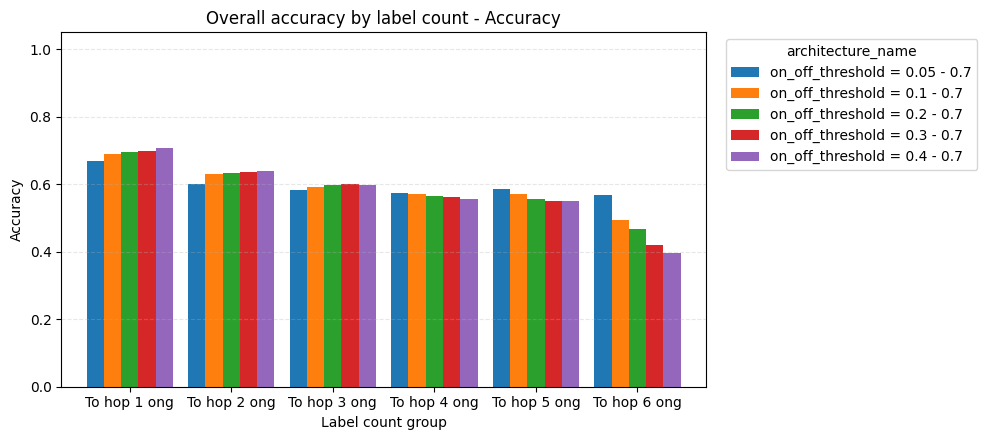

Saved plot to: /content/drive/MyDrive/Qeej_Hmong_Project/qeej_eval_results/summary_plots/overall_accuracy_by_label_count.png


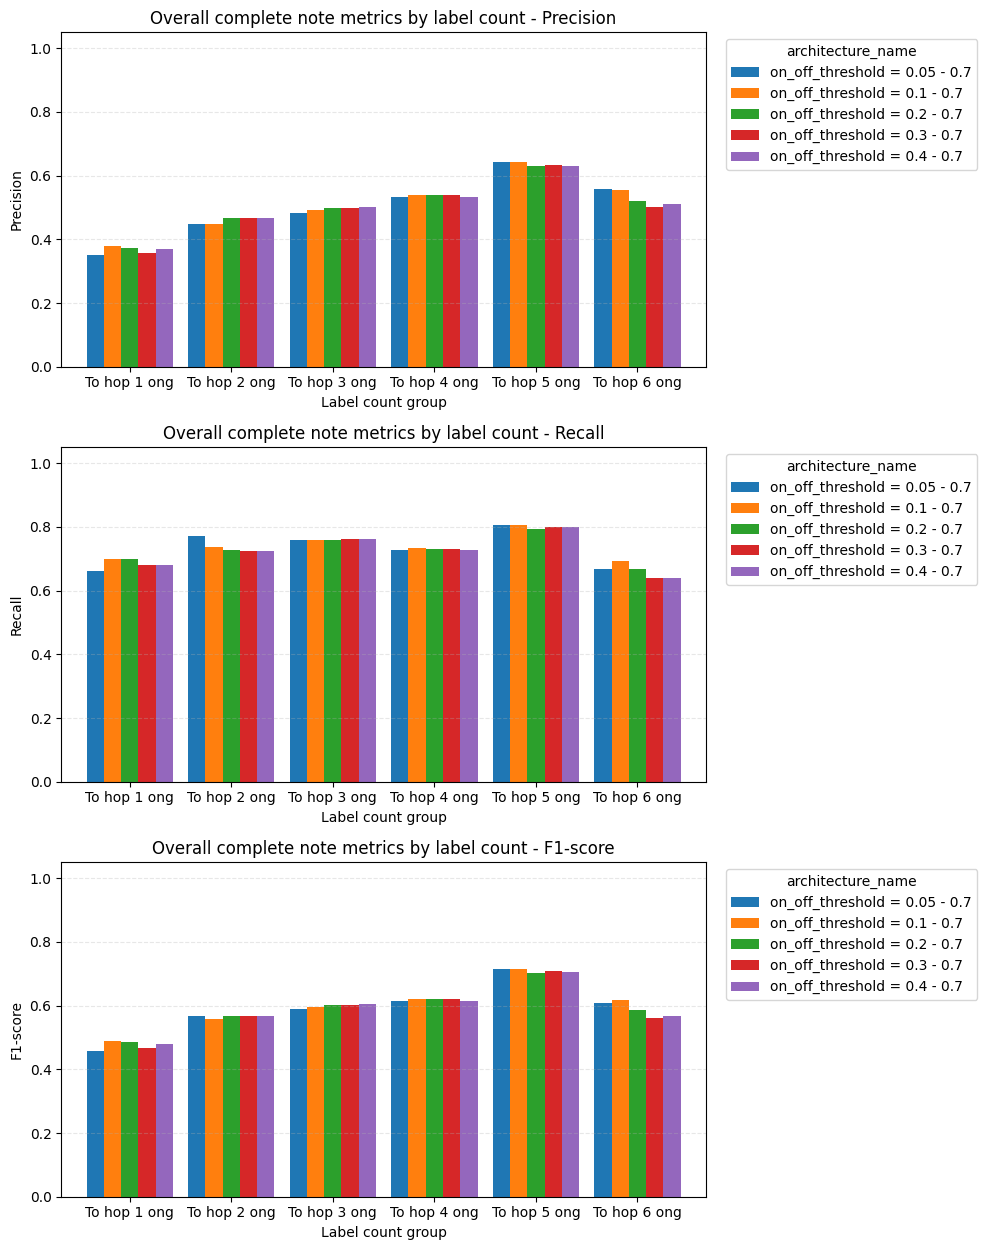

Saved plot to: /content/drive/MyDrive/Qeej_Hmong_Project/qeej_eval_results/summary_plots/overall_complete_note_metrics_by_label_count.png


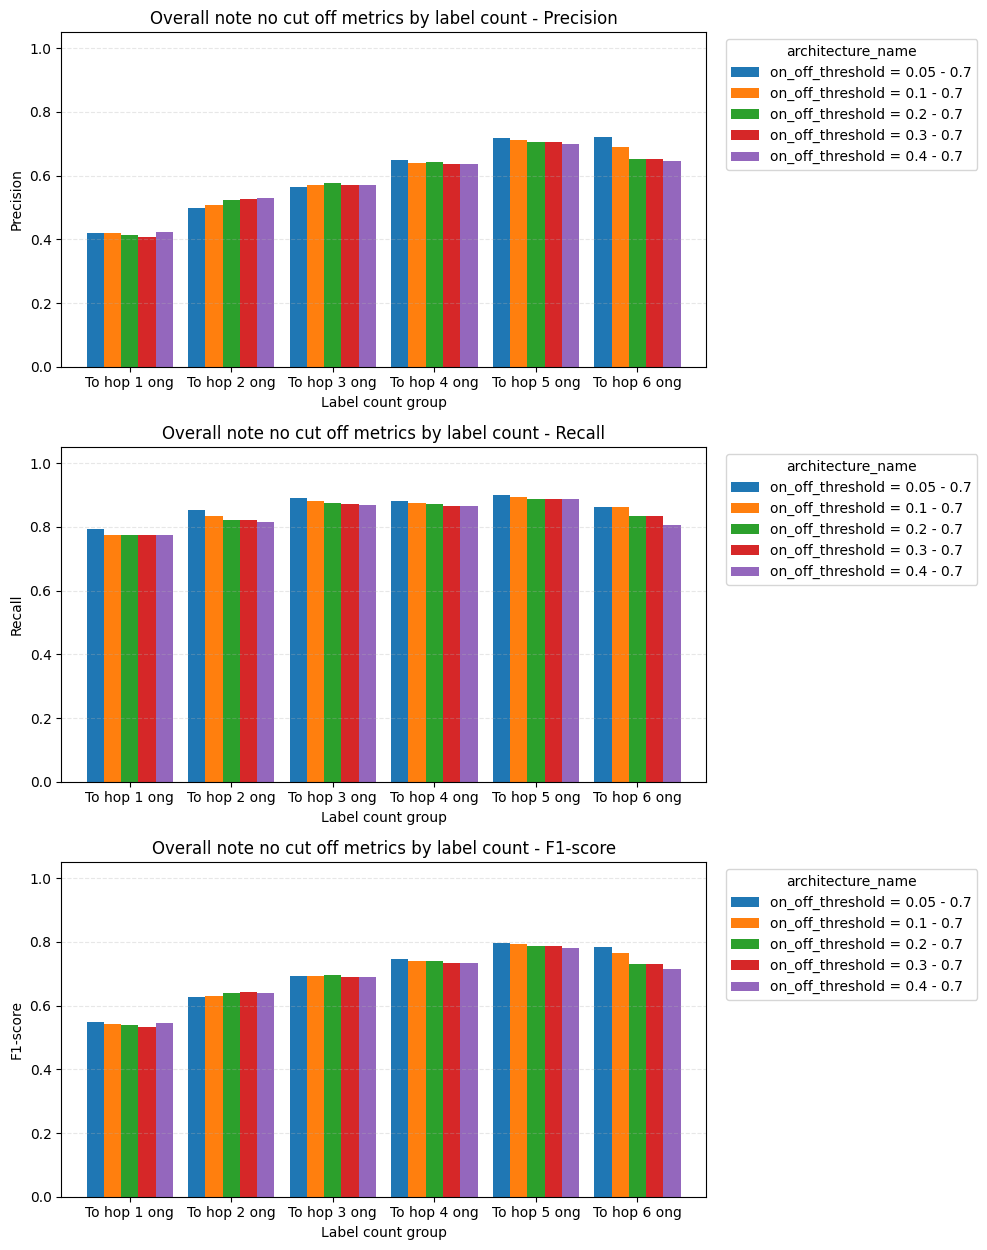

Saved plot to: /content/drive/MyDrive/Qeej_Hmong_Project/qeej_eval_results/summary_plots/overall_note_no_cut_off_metrics_by_label_count.png


In [ ]:
SUMMARY_PLOTS_DIR = os.path.join(QEEJ_EVAL_OUTPUT_DIR, "summary_plots")
os.makedirs(SUMMARY_PLOTS_DIR, exist_ok=True)

def extract_label_count_sort_key(label_count_group):
    matched = re.search(r"(\d+)", str(label_count_group))
    if matched is None:
        return 10**9
    return int(matched.group(1))

def get_architecture_order_from_df(metric_df):
    available_architectures = list(metric_df["architecture_name"].dropna().unique())
    ordered_architectures = [
        architecture_name
        for architecture_name in EVALUATED_ARCHITECTURE_MODEL
        if architecture_name in available_architectures
    ]
    remaining_architectures = [
        architecture_name
        for architecture_name in available_architectures
        if architecture_name not in ordered_architectures
    ]
    return ordered_architectures + remaining_architectures

def load_accuracy_plot_df(csv_path):
    accuracy_df = pd.read_csv(csv_path)
    first_column = accuracy_df.columns[0]
    if first_column != "label_count_group":
        accuracy_df = accuracy_df.rename(columns={first_column: "label_count_group"})

    plot_df = accuracy_df.melt(
        id_vars=["label_count_group"],
        var_name="architecture_name",
        value_name="metric_value",
    ).dropna(subset=["metric_value"])
    plot_df["metric_name"] = "accuracy"
    plot_df["label_count_sort"] = plot_df["label_count_group"].apply(extract_label_count_sort_key)
    return plot_df

def load_note_metric_plot_df(csv_path):
    metric_df = pd.read_csv(csv_path)
    first_column = metric_df.columns[0]
    if first_column != "label_count_group":
        metric_df = metric_df.rename(columns={first_column: "label_count_group"})

    plot_df = metric_df.melt(
        id_vars=["label_count_group"],
        var_name="architecture_metric_name",
        value_name="metric_value",
    ).dropna(subset=["metric_value"])
    plot_df["metric_name"] = plot_df["architecture_metric_name"].apply(lambda value: str(value).rsplit("_", 1)[-1])
    plot_df["architecture_name"] = plot_df["architecture_metric_name"].apply(lambda value: str(value).rsplit("_", 1)[0])
    plot_df = plot_df[plot_df["metric_name"].isin(["precision", "recall", "f1"])].copy()
    plot_df["label_count_sort"] = plot_df["label_count_group"].apply(extract_label_count_sort_key)
    return plot_df

def plot_metrics_by_label_count(plot_df, metric_names, title_prefix, save_path):
    if plot_df.empty:
        print(f"Skip plot because no data: {title_prefix}")
        return

    label_order = (
        plot_df[["label_count_group", "label_count_sort"]]
        .drop_duplicates()
        .sort_values(["label_count_sort", "label_count_group"])
    )["label_count_group"].tolist()
    architecture_order = get_architecture_order_from_df(plot_df)

    fig_width = max(10, len(label_order) * 1.6)
    fig_height = max(4.5, len(metric_names) * 4.2)
    fig, axes = plt.subplots(len(metric_names), 1, figsize=(fig_width, fig_height), squeeze=False)
    axes = axes.flatten()

    metric_title_map = {
        "accuracy": "Accuracy",
        "precision": "Precision",
        "recall": "Recall",
        "f1": "F1-score",
    }

    for ax, metric_name in zip(axes, metric_names):
        subset_df = plot_df[plot_df["metric_name"] == metric_name].copy()
        if subset_df.empty:
            ax.set_visible(False)
            continue

        pivot_df = subset_df.pivot(
            index="label_count_group",
            columns="architecture_name",
            values="metric_value",
        ).reindex(label_order)
        available_columns = [column_name for column_name in architecture_order if column_name in pivot_df.columns]
        remaining_columns = [column_name for column_name in pivot_df.columns if column_name not in available_columns]
        pivot_df = pivot_df[available_columns + remaining_columns]

        pivot_df.plot(kind="bar", ax=ax, width=0.85)
        ax.set_title(f"{title_prefix} - {metric_title_map.get(metric_name, metric_name)}")
        ax.set_xlabel("Label count group")
        ax.set_ylabel(metric_title_map.get(metric_name, metric_name))
        ax.set_ylim(0, 1.05)
        ax.grid(axis="y", linestyle="--", alpha=0.3)
        ax.tick_params(axis="x", rotation=0)
        ax.legend(title="architecture_name", bbox_to_anchor=(1.02, 1), loc="upper left")

    plt.tight_layout()
    fig.savefig(save_path, dpi=200, bbox_inches="tight")
    plt.show()
    print(f"Saved plot to: {save_path}")

accuracy_summary_path = os.path.join(QEEJ_EVAL_OUTPUT_DIR, "overall_accuracy_by_label_count.csv")
complete_note_summary_path = os.path.join(QEEJ_EVAL_OUTPUT_DIR, "overall_complete_note_metrics_by_label_count.csv")
note_no_cut_off_summary_path = os.path.join(QEEJ_EVAL_OUTPUT_DIR, "overall_note_no_cut_off_metrics_by_label_count.csv")

summary_plot_configs = [
    {
        "csv_path": accuracy_summary_path,
        "loader": load_accuracy_plot_df,
        "metric_names": ["accuracy"],
        "title_prefix": "Overall accuracy by label count",
        "save_path": os.path.join(SUMMARY_PLOTS_DIR, "overall_accuracy_by_label_count.png"),
    },
    {
        "csv_path": complete_note_summary_path,
        "loader": load_note_metric_plot_df,
        "metric_names": ["precision", "recall", "f1"],
        "title_prefix": "Overall complete note metrics by label count",
        "save_path": os.path.join(SUMMARY_PLOTS_DIR, "overall_complete_note_metrics_by_label_count.png"),
    },
    {
        "csv_path": note_no_cut_off_summary_path,
        "loader": load_note_metric_plot_df,
        "metric_names": ["precision", "recall", "f1"],
        "title_prefix": "Overall note no cut off metrics by label count",
        "save_path": os.path.join(SUMMARY_PLOTS_DIR, "overall_note_no_cut_off_metrics_by_label_count.png"),
    },
]

for config in summary_plot_configs:
    if not os.path.exists(config["csv_path"]):
        print(f"Skip plot because file does not exist: {config['csv_path']}")
        continue

    plot_df = config["loader"](config["csv_path"])
    plot_metrics_by_label_count(
        plot_df=plot_df,
        metric_names=config["metric_names"],
        title_prefix=config["title_prefix"],
        save_path=config["save_path"],
    )
